# Pairwise Fold Distribution Shift Analysis for Lo-Hi Hi Datasets

This notebook analyzes pairwise fold distribution shift for the Hi datasets used in the valid OOD-holdout vs random-shuffle protocol comparison: DRD2-Hi, HIV-Hi and Sol-Hi.

KDR-Hi is treated only as a diagnostic special case. Its outer training folds are restricted to 500 molecules and its reconstructed test subsets are not disjoint, so it is not included in the main shift-vs-protocol-benefit analysis.

## Methodology: Shift Detection as Binary Classification

We treat distribution-shift detection as a binary classification problem. For each dataset, we reconstruct the three original subsets as `F1 = test_3`, `F2 = test_2`, and `F3 = test_1`, then build the three pairwise discrimination tasks: `F1_vs_F2`, `F1_vs_F3`, and `F2_vs_F3`. In each task, molecules from the first subset receive label 0 and molecules from the second subset receive label 1. The activity label is not used.

Two complementary discrimination regimes are evaluated:
* **In-sample setting (high-capacity):** Estimates maximum separability using weakly regularized discriminators. This is only a diagnostic: if a model cannot separate two folds even in-sample, the two subsets are strongly overlapping in the chosen representation.
* **Out-of-sample setting:** Estimates generalizable shift using the same model families and hyperparameter search spaces used in the main OOD-vs-random protocol comparison. This second setting is the main shift estimate.

## Models and Representations

The discriminators are **Decision Tree (DT)**, **Logistic Regression (LR)**, and **Linear SVM**. Molecular representations include **ECFP4**, **MACCS**, and **RDKit descriptors**, although the main plots use only ECFP4 and MACCS to keep model/fingerprint comparisons aligned across DT, LR, and SVM. RDKit descriptors are retained in the CSV outputs for additional analysis. Continuous RDKit descriptors are scaled inside a pipeline; binary fingerprints are not scaled.

## The Shift Score

Throughout this study, we report the **shift score**:

$$s = 2 \cdot \text{balanced accuracy} - 1 \in [0,1]$$

Here, $s=0$ means that the two folds are not distinguishable by the discriminator, while $s=1$ means perfect distinguishability. This score is a monotonic rescaling of the proxy $\mathcal{A}$-distance from the domain-adaptation literature:

$$\hat{d}_{\mathcal{A}} = 2(1 - 2\epsilon)$$

Where $\epsilon$ is the discriminator error. Since balanced accuracy is $1-\epsilon$, we have:

$$s = \frac{\hat{d}_{\mathcal{A}}}{2}$$

> **Note:** We use $s$ in figures for readability and report $\hat{d}_{\mathcal{A}}$ in the CSV outputs for direct comparison with the domain-adaptation literature.

## Feature Extraction: List A vs. List B

The notebook also extracts the features used by the fold discriminators. 
* **List B (Shift features):** The features utilized by the fold discriminators to separate distributions.
* **List A (Activity features):** The activity-model features previously saved by the main OOD-vs-random study.

The List A vs List B overlap is computed fold-aware: for example, the shift features of `F1_vs_F2` are compared with the activity features from outer fold 1, because fold 1 uses `F1` and `F2` as the internal OOD train/validation pair.

## Linking to OOD-vs-Random Protocol

Finally, the notebook links the pairwise shift score to the OOD-vs-random protocol comparison. For each pair/fold, it computes both the difference in validation optimism and the final test benefit of OOD-based model selection. The main scatter plot uses:

$$\text{test gap} = \text{test PR-AUC}_{OOD} - \text{test PR-AUC}_{random}$$

Positive values indicate that OOD-based validation selected a model that performed better on the held-out OOD test fold.

# Pairwise Fold Distribution Shift Analysis for Lo-Hi Hi Datasets

In [1]:
from __future__ import annotations

import sys
import json
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

# issues should remain visible during the diagnostic analysis
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*X does not have valid feature names.*",
)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

##  Dataset Paths and Output Directories

In [2]:
DATASETS_MAIN = ["drd2", "hiv", "sol"]
DATASETS_DIAGNOSTIC = ["kdr"]
DATASETS = DATASETS_MAIN

TASK = "hi"

DATASET_LABELS = {
    "drd2": "DRD2",
    "hiv": "HIV",
    "sol": "Sol",
    "kdr": "KDR",
}

def find_project_root(start: Path | None = None) -> Path:
    """
    Walk upward until the project root is found.
    """
    if start is None:
        start = Path.cwd().resolve()

    current = start
    while current != current.parent:
        if (
            (current / "data").exists()
            and (current / "utils").exists()
            and (current / "results").exists()
        ):
            return current
        current = current.parent

    raise RuntimeError("Could not find project root containing data/, utils/, and results/.")

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.fingerprints import compute_fingerprints

OUT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FIG_ROOT = OUT_ROOT / "figures"

# Root feature cache directory
FEATURE_CACHE_ROOT = PROJECT_ROOT / "features" / "classifier_shift_test" / TASK

for d in (OUT_ROOT, FIG_ROOT, FEATURE_CACHE_ROOT):
    d.mkdir(parents=True, exist_ok=True)

FINGERPRINTS = ["ecfp4", "maccs", "rdkit_desc"]

TOPK_VALUES = [10, 20, 50]

N_CV_SPLITS = 5

print(f"Datasets     : {DATASETS}")
print(f"Task         : {TASK}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Output root  : {OUT_ROOT}")
print(f"Figure root  : {FIG_ROOT}")
print(f"Feature cache: {FEATURE_CACHE_ROOT}")

Datasets     : ['drd2', 'hiv', 'sol']
Task         : hi
Project root : /home/f.capria/drug-discovery-lohi
Output root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi
Figure root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/figures
Feature cache: /home/f.capria/drug-discovery-lohi/features/classifier_shift_test/hi


## Sanity Check: Input Data and Previous Results

In [3]:
def get_dataset_paths(dataset: str) -> dict:
    """
    Return all input/output paths for one Hi dataset.
    """
    data_dir = PROJECT_ROOT / "data" / TASK / dataset

    binding_results_dir = (
        PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK / dataset
    )

    out_dir = OUT_ROOT / dataset
    fig_dir = out_dir / "figures"
    feat_dir = out_dir / "discriminator_features"
    feature_cache_dir = FEATURE_CACHE_ROOT / dataset

    for d in (out_dir, fig_dir, feat_dir, feature_cache_dir):
        d.mkdir(parents=True, exist_ok=True)

    return {
        "data_dir": data_dir,
        "binding_results_dir": binding_results_dir,
        "out_dir": out_dir,
        "fig_dir": fig_dir,
        "feat_dir": feat_dir,
        "feature_cache_dir": feature_cache_dir,
    }

## Reconstruct Hi Subsets and Pairwise Fold Task

In [4]:
for dataset in DATASETS:
    paths = get_dataset_paths(dataset)
    data_dir = paths["data_dir"]

    print(f"\nChecking {dataset}-{TASK}")
    print("Data dir:", data_dir)

    assert data_dir.exists(), f"Missing data directory: {data_dir}"

    for fname in ["test_1.csv", "test_2.csv", "test_3.csv"]:
        path = data_dir / fname
        assert path.exists(), f"Missing file: {path}"

    if not paths["binding_results_dir"].exists():
        print(f"Warning: binding results directory not found: {paths['binding_results_dir']}")
        print("Feature overlap with activity models will be skipped unless this directory exists.")
    else:
        print("Binding results directory found.")


Checking drd2-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/drd2
Feature overlap with activity models will be skipped unless this directory exists.

Checking hiv-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/hiv
Feature overlap with activity models will be skipped unless this directory exists.

Checking sol-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/sol
Feature overlap with activity models will be skipped unless this directory exists.


In [5]:
SUBSET_FILES = {
    "F1": "test_3.csv",
    "F2": "test_2.csv",
    "F3": "test_1.csv",
}

PAIRS = list(combinations(["F1", "F2", "F3"], 2))


def load_subsets(dataset: str) -> dict[str, pd.DataFrame]:
    paths = get_dataset_paths(dataset)
    data_dir = paths["data_dir"]

    subsets = {}
    for subset_name, filename in SUBSET_FILES.items():
        path = data_dir / filename
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path).copy()
        df["subset"] = subset_name
        df["source_file"] = filename
        subsets[subset_name] = df

    return subsets


for dataset in DATASETS:
    subsets_tmp = load_subsets(dataset)
    print(f"\n{dataset.upper()}-{TASK}")
    for subset_name, df in subsets_tmp.items():
        print(f"  {subset_name} ({SUBSET_FILES[subset_name]}): {len(df)} molecules")
    print(f"  Pairs: {PAIRS}")


DRD2-hi
  F1 (test_3.csv): 1191 molecules
  F2 (test_2.csv): 1194 molecules
  F3 (test_1.csv): 1190 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

HIV-hi
  F1 (test_3.csv): 7848 molecules
  F2 (test_2.csv): 7848 molecules
  F3 (test_1.csv): 7847 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

SOL-hi
  F1 (test_3.csv): 721 molecules
  F2 (test_2.csv): 721 molecules
  F3 (test_1.csv): 721 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]


## Featurization and pair dataset builder

In [6]:
def get_smiles_col(df: pd.DataFrame) -> str:
    """Return the SMILES column name."""
    for col in ["smiles", "SMILES", "canonical_smiles"]:
        if col in df.columns:
            return col
    raise ValueError(f"No SMILES column found. Available columns: {df.columns.tolist()}")


def get_feature_names(fp_type: str, n_features: int) -> list[str]:
    """Return feature names for each molecular representation."""
    if fp_type == "ecfp4":
        return [f"ecfp4_bit_{i}" for i in range(n_features)]

    if fp_type == "maccs":
        return [f"maccs_key_{i}" for i in range(n_features)]

    if fp_type == "rdkit_desc":
        try:
            from rdkit import Chem
            from rdkit.Chem import Descriptors

            # Match the exact order used in utils.fingerprints.compute_rdkit_descriptors, which 
            # relies on Descriptors.CalcMolDescriptors(mol).values().
            ref_mol = Chem.MolFromSmiles("CC")
            calc_desc = Descriptors.CalcMolDescriptors(ref_mol)
            names = list(calc_desc.keys())

            if len(names) != n_features:
                raise ValueError(
                    f"RDKit descriptor name mismatch: got {len(names)} names "
                    f"for {n_features} features."
                )

            desc_list_names = [name for name, _ in Descriptors._descList]

            if names != desc_list_names[:len(names)]:
                warnings.warn(
                    "RDKit descriptor order from CalcMolDescriptors does not exactly "
                    "match Descriptors._descList. Using CalcMolDescriptors order."
                )

            return names

        except Exception as e:
            warnings.warn(
                f"Could not recover RDKit descriptor names reliably: {e}. "
                "Falling back to index-based descriptor names."
            )
            return [f"rdkit_desc_{i}" for i in range(n_features)]

    return [f"{fp_type}_feature_{i}" for i in range(n_features)]


def build_pair_dataset(
    dataset: str,
    subsets: dict[str, pd.DataFrame],
    fold_a: str,
    fold_b: str,
    fp_type: str,
) -> tuple[np.ndarray, np.ndarray, list[str], pd.DataFrame]:
    """
    Build one binary fold-discrimination dataset.

    Label convention:
        fold_a -> 0
        fold_b -> 1

    Invalid SMILES are removed after featurization using the valid_mask returned
    by compute_fingerprints(), so X, y and pair_df remain aligned.
    """
    df_a = subsets[fold_a].copy()
    df_b = subsets[fold_b].copy()

    smiles_col = get_smiles_col(df_a)
    pair_name = f"{fold_a}_vs_{fold_b}"

    df_a["shift_label"] = 0
    df_b["shift_label"] = 1

    pair_df = pd.concat([df_a, df_b], ignore_index=True)
    pair_df["dataset"] = dataset
    pair_df["pair"] = pair_name
    pair_df["fold_a"] = fold_a
    pair_df["fold_b"] = fold_b

    smiles = pair_df[smiles_col].astype(str).tolist()

    cache_path = (
        get_dataset_paths(dataset)["feature_cache_dir"]
        / f"{pair_name}_{fp_type}.npz"
    )

    X, valid_mask = compute_fingerprints(
        smiles_list=smiles,
        fp_type=fp_type,
        cache_path=cache_path,
    )

    valid_mask = np.asarray(valid_mask, dtype=bool)

    if len(valid_mask) != len(pair_df):
        raise ValueError(
            f"valid_mask length mismatch for {dataset} {pair_name} {fp_type}: "
            f"{len(valid_mask)} vs {len(pair_df)}"
        )

    n_invalid = int((~valid_mask).sum())
    if n_invalid > 0:
        print(
            f"Removed {n_invalid} invalid SMILES from "
            f"{dataset} | {pair_name} | {fp_type}"
        )

    pair_df = pair_df.loc[valid_mask].reset_index(drop=True)
    y = pair_df["shift_label"].to_numpy(dtype=int)

    if X.shape[0] != len(y):
        raise ValueError(
            f"Feature/label mismatch for {dataset} {pair_name} {fp_type}: "
            f"X has {X.shape[0]} rows, y has {len(y)} rows."
        )

    feature_names = get_feature_names(fp_type, X.shape[1])

    return X, y, feature_names, pair_df

## Utility: Suppress RDKit and Featurization Logs

In [7]:
import os
import contextlib
from rdkit import RDLogger

VERBOSE = False

@contextlib.contextmanager
def silence_output():
    """
    Suppress noisy stdout/stderr and RDKit logs during featurization and fitting.
    """
    RDLogger.DisableLog("rdApp.*")
    with open(os.devnull, "w") as devnull:
        with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
            yield
    RDLogger.EnableLog("rdApp.*")

## High-Capacity In-Sample Discrimination

In [8]:
def make_high_capacity_discriminators(fp_type: str) -> dict:
    """
    High-capacity / weakly-regularized fold discriminators.
    Used only for in-sample maximum separability.
    """
    scale = fp_type == "rdkit_desc"

    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        ccp_alpha=0.0,
        random_state=RANDOM_STATE,
    )

    lr = LogisticRegression(
        C=1e4,
        l1_ratio=0.0,
        solver="saga",
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    svm = LinearSVC(
        C=1e4,
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    if scale:
        lr = Pipeline([
            ("scaler", StandardScaler()),
            ("model", lr),
        ])
        svm = Pipeline([
            ("scaler", StandardScaler()),
            ("model", svm),
        ])

    return {
        "DT": dt,
        "LR": lr,
        "SVM": svm,
    }


def shift_scores_from_balanced_accuracy(bal_acc: float) -> tuple[float, float]:
    """
    Convert balanced accuracy into two equivalent fold-shift scores.

    shift_score_01:
        s = max(0, 2 * balanced_accuracy - 1)

        s = 0 means that the discriminator is not better than chance.
        s = 1 means perfect fold distinguishability.

    proxy_A_distance:
        d_A = 2 * s

        This matches the proxy A-distance definition:
            d_A = 2 * (1 - 2 * error)

        Since balanced_accuracy = 1 - error:
            d_A = 2 * (2 * balanced_accuracy - 1)

    We clip at zero because balanced accuracy below 0.5 means the discriminator
    is not distinguishable above chance in the chosen orientation.
    """
    if not np.isfinite(bal_acc):
        return np.nan, np.nan

    shift_score_01 = max(0.0, 2.0 * float(bal_acc) - 1.0)
    proxy_a_distance = 2.0 * shift_score_01

    return shift_score_01, proxy_a_distance


insample_rows = []
fitted_high_capacity = {}

for dataset in DATASETS:
    subsets = load_subsets(dataset)

    if VERBOSE:
        print(f"\n=== High-capacity in-sample discrimination: {dataset.upper()}-{TASK} ===")

    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        for fp_type in FINGERPRINTS:
            try:
                with silence_output():
                    X, y, feature_names, pair_df = build_pair_dataset(
                        dataset=dataset,
                        subsets=subsets,
                        fold_a=fold_a,
                        fold_b=fold_b,
                        fp_type=fp_type,
                    )
            except Exception as e:
                print(f"Skip {dataset} | {pair_name} | {fp_type}: {e}")
                continue

            for model_name, model in make_high_capacity_discriminators(fp_type).items():
                if VERBOSE:
                    print(f"{dataset} | {pair_name} | {fp_type} | {model_name}")

                fitted = clone(model)

                with silence_output():
                    fitted.fit(X, y)

                y_pred = fitted.predict(X)

                acc = accuracy_score(y, y_pred)
                bal_acc = balanced_accuracy_score(y, y_pred)
                shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(bal_acc)

                insample_rows.append({
                    "dataset": dataset,
                    "task": TASK,
                    "pair": pair_name,
                    "fold_a": fold_a,
                    "fold_b": fold_b,
                    "fingerprint": fp_type,
                    "model": model_name,
                    "evaluation": "high_capacity_insample",
                    "accuracy": acc,
                    "balanced_accuracy": bal_acc,
                    "shift_score_01": shift_score_01,
                    "proxy_A_distance": proxy_a_distance,
                    "n_samples": len(y),
                    "n_class_0": int((y == 0).sum()),
                    "n_class_1": int((y == 1).sum()),
                    "main_shift_estimate": False
                })

                fitted_high_capacity[(dataset, pair_name, fp_type, model_name)] = {
                    "model": fitted,
                    "feature_names": feature_names,
                    "X": X,
                    "y": y,
                    "pair_df": pair_df,
                }

df_insample = pd.DataFrame(insample_rows)

for dataset, sub in df_insample.groupby("dataset"):
    out_path = (
        get_dataset_paths(dataset)["out_dir"]
        / "discrimination_high_capacity_insample.csv"
    )
    sub.to_csv(out_path, index=False)

df_insample.to_csv(
    OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv",
    index=False,
)

display(
    df_insample
    .pivot_table(
        index=["dataset", "pair", "fingerprint"],
        columns="model",
        values="balanced_accuracy",
    )
    .round(3)
)

model                            DT     LR    SVM
dataset pair     fingerprint                     
drd2    F1_vs_F2 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.957  0.952
                 rdkit_desc   1.000  0.974  0.982
        F1_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.932  0.927
                 rdkit_desc   1.000  0.950  0.961
        F2_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.974  0.972
                 rdkit_desc   1.000  0.977  0.984
hiv     F1_vs_F2 ecfp4        1.000  0.847  0.845
                 maccs        1.000  0.690  0.692
                 rdkit_desc   1.000  0.698  0.699
        F1_vs_F3 ecfp4        1.000  0.828  0.828
                 maccs        1.000  0.688  0.690
                 rdkit_desc   1.000  0.705  0.707
        F2_vs_F3 ecfp4        1.000  0.872  0.871
                 maccs        0.999  0.734  0.735
                 rdkit_desc   1.000  0.749  0.750
sol     F1_vs_F2 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.651  0.655
                 rdkit_desc   1.000  0.678  0.687
        F1_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        0.999  0.714  0.716
                 rdkit_desc   1.000  0.725  0.734
        F2_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.693  0.692
                 rdkit_desc   1.000  0.702  0.705

## Same-Search Out-of-Sample Discrimination

In [9]:
from sklearn.model_selection import GridSearchCV


def allowed_fingerprints_for_model(model_name: str) -> list[str]:
    """
    Match the fingerprint availability of the main OOD-vs-random study.
    """
    if model_name == "LR":
        return ["ecfp4", "maccs", "rdkit_desc"]
    if model_name in ["DT", "SVM"]:
        return ["ecfp4", "maccs"]
    raise ValueError(f"Unknown model_name: {model_name}")

def make_lr_base_for_project(dataset: str) -> LogisticRegression:
    """
    Build the LogisticRegression discriminator for the classifier-shift analysis.

    In sklearn >= 1.8, `penalty` is deprecated. We therefore leave `penalty`
    at its default value and control the regularization family through l1_ratio:

        l1_ratio = 0.0       -> L2-like
        l1_ratio = 1.0       -> L1-like
        0 < l1_ratio < 1.0  -> ElasticNet-like

    This matches the compatibility logic used in training/train_model.py.
    """
    max_iter = 8000 if dataset == "hiv" else 15000
    tol = 0.002 if dataset == "hiv" else 0.001

    return LogisticRegression(
        solver="saga",
        max_iter=max_iter,
        tol=tol,
        random_state=RANDOM_STATE,
    )

def get_main_search_grid(dataset: str, model_name: str) -> dict:
    """
    Return the same hyperparameter grid used in the main OOD-vs-random study.

    HIV uses reduced grids for computational reasons, consistently with
    the main experiments.
    """
    is_hiv = dataset == "hiv"

    if model_name == "DT":
        if is_hiv:
            return {
                "max_depth": [3, 5, 8, 10, 15],
                "min_samples_split": [10, 20, 50],
                "min_samples_leaf": [5, 10, 20, 50],
                "criterion": ["gini", "entropy"],
                "class_weight": [None, "balanced"],
                "max_features": ["sqrt", "log2"],
                "ccp_alpha": [0.0, 0.0001, 0.001],
            }

        return {
            "max_depth": [3, 5, 7, 10, 15, 20],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "criterion": ["gini", "entropy"],
            "class_weight": [None, "balanced"],
            "max_features": ["sqrt", "log2", None],
            "ccp_alpha": [0.0, 0.0001, 0.001, 0.01],
        }

    if model_name == "LR":
        if is_hiv:
            return {
                "C": [0.01, 0.1, 1.0],
                "l1_ratio": [0.0, 1.0],
                "class_weight": [None, "balanced"],
            }

        return {
            "C": [0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
            "class_weight": [None, "balanced"],
        }

    if model_name == "SVM":
        if is_hiv:
            return {
                "C": [0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
                "class_weight": [None, "balanced"],
            }

        return {
            "C": [
                0.001, 0.005, 0.01, 0.05, 0.1,
                0.25, 0.5, 1.0, 2.0, 5.0,
                10.0, 25.0, 50.0, 100.0,
            ],
            "class_weight": [None, "balanced"],
        }

    raise ValueError(f"Unknown model_name: {model_name}")


def make_main_search_discriminator(dataset: str, fp_type: str, model_name: str):
    """
    Build discriminator + grid using the same search space as the main
    protocol-comparison study where possible.

    For LR, this classifier-shift analysis follows the sklearn >= 1.8 convention:
    penalty is left at its default value and l1_ratio controls the L1/L2/ElasticNet-like behavior.
    """
    if fp_type not in allowed_fingerprints_for_model(model_name):
        return None, None

    if model_name == "DT":
        estimator = DecisionTreeClassifier(random_state=RANDOM_STATE)
        grid = get_main_search_grid(dataset, model_name)

    elif model_name == "LR":
        base = make_lr_base_for_project(dataset)
        grid = get_main_search_grid(dataset, model_name)

        if "penalty" in grid:
            raise ValueError(
                "LR grid should not contain `penalty` here. "
                "This notebook fixes penalty='elasticnet' and searches over l1_ratio."
            )

        if "l1_ratio" not in grid:
            raise ValueError(
                "LR grid must contain `l1_ratio` to control the L1/L2/ElasticNet-like behavior."            )

        if fp_type == "rdkit_desc":
            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("model", base),
            ])
            grid = {f"model__{k}": v for k, v in grid.items()}
        else:
            estimator = base

    elif model_name == "SVM":
        estimator = LinearSVC(
            max_iter=20000,
            random_state=RANDOM_STATE,
        )
        grid = get_main_search_grid(dataset, model_name)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return estimator, grid

# estimator, grid = make_main_search_discriminator("drd2", "ecfp4", "LR")
# print(estimator)
# print(grid)

# estimator, grid = make_main_search_discriminator("drd2", "rdkit_desc", "LR")
# print(estimator)
# print(grid)

search_cv_rows = []
best_search_models = {}

skf = StratifiedKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

for dataset in DATASETS:
    subsets = load_subsets(dataset)

    if VERBOSE:
        print(f"\n=== Same-search out-of-sample discrimination: {dataset.upper()}-{TASK} ===")

    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        for fp_type in FINGERPRINTS:
            try:
                with silence_output():
                    X, y, feature_names, pair_df = build_pair_dataset(
                        dataset=dataset,
                        subsets=subsets,
                        fold_a=fold_a,
                        fold_b=fold_b,
                        fp_type=fp_type,
                    )
            except Exception as e:
                print(f"Skip {dataset} | {pair_name} | {fp_type}: {e}")
                continue

            for model_name in ["DT", "LR", "SVM"]:
                estimator, param_grid = make_main_search_discriminator(
                    dataset=dataset,
                    fp_type=fp_type,
                    model_name=model_name,
                )

                if estimator is None:
                    continue

                if VERBOSE:
                    print(f"{dataset} | {pair_name} | {fp_type} | {model_name}")

                search = GridSearchCV(
                        estimator=estimator,
                        param_grid=param_grid,
                        scoring={
                            "accuracy": "accuracy",
                            "balanced_accuracy": "balanced_accuracy",
                            "roc_auc": "roc_auc",
                        },
                        refit="balanced_accuracy",
                        cv=skf,
                        n_jobs=-1,
                        return_train_score=True,
                        error_score="raise",
                )

                search.fit(X, y)

                best_idx = search.best_index_
                cvres = search.cv_results_
                
                metric_keys = [
                    "mean_test_accuracy",
                    "mean_test_balanced_accuracy",
                    "mean_test_roc_auc",
                    "mean_train_balanced_accuracy",
                ]

                for key in metric_keys:
                    if key not in cvres:
                        raise ValueError(
                            f"Missing GridSearchCV result key {key} for "
                            f"{dataset}|{pair_name}|{fp_type}|{model_name}"
                        )

                    values = np.asarray(cvres[key], dtype=float)

                    if np.isnan(values).any():
                        raise ValueError(
                            f"NaN detected in {key} for "
                            f"{dataset}|{pair_name}|{fp_type}|{model_name}. "
                            "This indicates that at least one candidate/fold failed."
                        )

                acc_mean = float(cvres["mean_test_accuracy"][best_idx])
                acc_std = float(cvres["std_test_accuracy"][best_idx])

                bal_mean = float(cvres["mean_test_balanced_accuracy"][best_idx])
                bal_std = float(cvres["std_test_balanced_accuracy"][best_idx])

                roc_mean = float(cvres["mean_test_roc_auc"][best_idx])
                roc_std = float(cvres["std_test_roc_auc"][best_idx])

                train_bal_mean = float(cvres["mean_train_balanced_accuracy"][best_idx])
                train_bal_std = float(cvres["std_train_balanced_accuracy"][best_idx])
                
                best_metrics = {
                    "acc_mean": acc_mean,
                    "bal_mean": bal_mean,
                    "roc_mean": roc_mean,
                    "train_bal_mean": train_bal_mean,
                }

                for metric_name, metric_value in best_metrics.items():
                    if not np.isfinite(metric_value):
                        raise ValueError(
                            f"Non-finite {metric_name} for "
                            f"{dataset}|{pair_name}|{fp_type}|{model_name}: {metric_value}"
                    )

                shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(
                    bal_mean
                )

                search_cv_rows.append({
                    "dataset": dataset,
                    "task": TASK,
                    "pair": pair_name,
                    "fold_a": fold_a,
                    "fold_b": fold_b,
                    "fingerprint": fp_type,
                    "model": model_name,
                    "evaluation": "same_search_cv",
                    "main_shift_estimate": True,
                    "cv_accuracy_mean": acc_mean,
                    "cv_accuracy_std": acc_std,
                    "cv_balanced_accuracy_mean": bal_mean,
                    "cv_balanced_accuracy_std": bal_std,
                    "cv_roc_auc_mean": roc_mean,
                    "cv_roc_auc_std": roc_std,
                    "cv_train_balanced_accuracy_mean": train_bal_mean,
                    "cv_train_balanced_accuracy_std": train_bal_std,
                    "cv_train_test_gap_balanced_accuracy": train_bal_mean - bal_mean,
                    "shift_score_01": shift_score_01,
                    "proxy_A_distance": proxy_a_distance,
                    "best_params": json.dumps(search.best_params_),
                    "n_samples": len(y),
                    "n_class_0": int((y == 0).sum()),
                    "n_class_1": int((y == 1).sum()),
                })

                best_search_models[(dataset, pair_name, fp_type, model_name)] = {
                    "model": search.best_estimator_,
                    "feature_names": feature_names,
                    "X": X,
                    "y": y,
                    "pair_df": pair_df,
                    "best_params": search.best_params_,
                }

df_search_cv = pd.DataFrame(search_cv_rows)

for dataset, sub in df_search_cv.groupby("dataset"):
    out_path = (
        get_dataset_paths(dataset)["out_dir"]
        / "discrimination_same_search_cv.csv"
    )
    sub.to_csv(out_path, index=False)

df_search_cv.to_csv(
    OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv",
    index=False,
)

display(
    df_search_cv
    .pivot_table(
        index=["dataset", "pair", "fingerprint"],
        columns="model",
        values="proxy_A_distance",
    )
    .round(3)
)

model                            DT     LR    SVM
dataset pair     fingerprint                     
drd2    F1_vs_F2 ecfp4        1.862  1.953  1.953
                 maccs        1.770  1.706  1.715
                 rdkit_desc     NaN  1.762    NaN
        F1_vs_F3 ecfp4        1.819  1.874  1.882
                 maccs        1.736  1.620  1.612
                 rdkit_desc     NaN  1.639    NaN
        F2_vs_F3 ecfp4        1.829  1.928  1.943
                 maccs        1.832  1.787  1.792
                 rdkit_desc     NaN  1.794    NaN
hiv     F1_vs_F2 ecfp4        0.714  1.099  1.108
                 maccs        0.858  0.726  0.735
                 rdkit_desc     NaN  0.762    NaN
        F1_vs_F3 ecfp4        0.685  0.982  0.984
                 maccs        0.777  0.711  0.713
                 rdkit_desc     NaN  0.766    NaN
        F2_vs_F3 ecfp4        0.894  1.217  1.220
                 maccs        0.948  0.898  0.898
                 rdkit_desc     NaN  0.940    NaN
sol     F1_vs_F2 ecfp4        0.324  0.635  0.624
                 maccs        0.380  0.236  0.241
                 rdkit_desc     NaN  0.349    NaN
        F1_vs_F3 ecfp4        0.624  0.871  0.860
                 maccs        0.499  0.571  0.580
                 rdkit_desc     NaN  0.566    NaN
        F2_vs_F3 ecfp4        0.627  0.838  0.827
                 maccs        0.555  0.483  0.480
                 rdkit_desc     NaN  0.505    NaN

## Extract List B: Fold-Discriminator Feature Importances

In [10]:
def get_base_model(model):
    """Return final estimator if model is a Pipeline."""
    return model.steps[-1][1] if isinstance(model, Pipeline) else model


def tree_minimum_depths(tree_model, n_features: int) -> np.ndarray:
    """
    Minimum depth at which each feature appears in a fitted Decision Tree.
    Features never used receive NaN.
    """
    tree = tree_model.tree_
    min_depth = np.full(n_features, np.nan)

    stack = [(0, 0)]  # node_id, depth

    while stack:
        node_id, depth = stack.pop()
        feature_id = tree.feature[node_id]

        if feature_id >= 0:
            if np.isnan(min_depth[feature_id]) or depth < min_depth[feature_id]:
                min_depth[feature_id] = depth

            left = tree.children_left[node_id]
            right = tree.children_right[node_id]

            if left != -1:
                stack.append((left, depth + 1))
            if right != -1:
                stack.append((right, depth + 1))

    return min_depth


def extract_discriminator_importance(
    fitted_model,
    feature_names: list[str],
    model_name: str,
) -> pd.DataFrame:
    """
    Extract feature importances from a fitted fold discriminator.

    DT:
        - impurity-based feature importance
        - minimum depth

    LR/SVM:
        - coefficient
        - absolute coefficient as importance

    Caveat:
        For DT, List B uses impurity-based importance, while the activity-model
        List A table uses permutation importance. Therefore DT List A/List B
        overlap is exploratory and should be interpreted more cautiously than
        LR/SVM overlap.
    """
    base = get_base_model(fitted_model)
    n_features = len(feature_names)

    if model_name == "DT":
        importance = np.asarray(base.feature_importances_)
        min_depth = tree_minimum_depths(base, n_features)

        df = pd.DataFrame({
            "feature_idx": np.arange(n_features),
            "feature_name": feature_names,
            "importance": importance,
            "abs_importance": importance,
            "coefficient": np.nan,
            "direction": "tree",
            "minimum_depth": min_depth,
            "used": importance > 0,
            "importance_source": "impurity_importance",
        })

    else:
        coef = np.asarray(base.coef_).ravel()
        importance = np.abs(coef)

        df = pd.DataFrame({
            "feature_idx": np.arange(len(coef)),
            "feature_name": feature_names[:len(coef)],
            "importance": importance,
            "abs_importance": importance,
            "coefficient": coef,
            "direction": np.where(coef > 0, "towards_fold_b",
                          np.where(coef < 0, "towards_fold_a", "zero")),
            "minimum_depth": np.nan,
            "used": importance > 0,
            "importance_source": "absolute_coefficient",
        })

    total = df["abs_importance"].sum()
    df["normalized_importance"] = (
        df["abs_importance"] / total if total > 0 else 0.0
    )

    df = df.sort_values(
        ["abs_importance", "minimum_depth"],
        ascending=[False, True],
        na_position="last",
    ).reset_index(drop=True)

    df["rank"] = np.arange(1, len(df) + 1)

    return df


def collect_listB_from_models(model_dict: dict, source_name: str) -> pd.DataFrame:
    """
    Extract List B shift features from a fitted-model dictionary.

    Expected key:
        (dataset, pair_name, fp_type, model_name)

    Expected value:
        {
            "model": fitted estimator,
            "feature_names": list,
            ...
        }
    """
    all_rows = []

    for (dataset, pair_name, fp_type, model_name), obj in model_dict.items():
        fitted_model = obj["model"]
        feature_names = obj["feature_names"]

        df_imp = extract_discriminator_importance(
            fitted_model=fitted_model,
            feature_names=feature_names,
            model_name=model_name,
        )

        fold_a, fold_b = pair_name.split("_vs_")

        df_imp.insert(0, "source", source_name)
        df_imp.insert(0, "model", model_name)
        df_imp.insert(0, "fingerprint", fp_type)
        df_imp.insert(0, "fold_b", fold_b)
        df_imp.insert(0, "fold_a", fold_a)
        df_imp.insert(0, "pair", pair_name)
        df_imp.insert(0, "task", TASK)
        df_imp.insert(0, "dataset", dataset)

        all_rows.append(df_imp)

        top = df_imp.head(50)
        feat_dir = get_dataset_paths(dataset)["feat_dir"]
        top.to_csv(
            feat_dir / f"listB_{source_name}_{pair_name}_{fp_type}_{model_name}.csv",
            index=False,
        )

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()


listB_parts = []

if "fitted_high_capacity" in globals() and fitted_high_capacity:
    listB_parts.append(
        collect_listB_from_models(
            model_dict=fitted_high_capacity,
            source_name="high_capacity_insample",
        )
    )

if "best_search_models" in globals() and best_search_models:
    listB_parts.append(
        collect_listB_from_models(
            model_dict=best_search_models,
            source_name="same_search_cv",
        )
    )

df_listB = pd.concat(listB_parts, ignore_index=True)

# Save dataset-specific full List B tables
for dataset, sub in df_listB.groupby("dataset"):
    sub.to_csv(
        get_dataset_paths(dataset)["out_dir"] / "listB_discriminator_feature_importance.csv",
        index=False,
    )

# Save cross-dataset full List B table
df_listB.to_csv(
    OUT_ROOT / "cross_dataset_listB_discriminator_feature_importance.csv",
    index=False,
)

df_listB_main = df_listB[df_listB["source"] == "same_search_cv"].copy()
df_listB_insample = df_listB[df_listB["source"] == "high_capacity_insample"].copy()

df_listB_main.to_csv(
    OUT_ROOT / "cross_dataset_listB_same_search_cv_feature_importance.csv",
    index=False,
)

df_listB_insample.to_csv(
    OUT_ROOT / "cross_dataset_listB_high_capacity_insample_feature_importance.csv",
    index=False,
)

print(
    "Saved List B feature-importance tables:\n"
    f"  full mixed-source table: {len(df_listB)} rows\n"
    f"  same_search_cv only    : {len(df_listB_main)} rows\n"
    f"  high_capacity only     : {len(df_listB_insample)} rows\n"
    "Use same_search_cv for the main List A/List B overlap analysis."
)

display(
    df_listB
    .query("rank <= 10")
    .loc[:, [
        "dataset", "source", "pair", "fingerprint", "model",
        "rank", "feature_idx", "feature_name",
        "abs_importance", "coefficient", "direction", "minimum_depth"
    ]]
    .head(30)
)

Saved List B feature-importance tables:
  full mixed-source table: 127422 rows
  same_search_cv only    : 61758 rows
  high_capacity only     : 65664 rows
Use same_search_cv for the main List A/List B overlap analysis.


,dataset,source,pair,fingerprint,model,rank,feature_idx,feature_name,abs_importance,coefficient,direction,minimum_depth
0,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,1,1671,ecfp4_bit_1671,0.255939,NaN,tree,0.0
1,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,2,197,ecfp4_bit_197,0.111085,NaN,tree,1.0
2,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,3,1303,ecfp4_bit_1303,0.083490,NaN,tree,2.0
3,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,4,1292,ecfp4_bit_1292,0.070440,NaN,tree,4.0
4,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,5,231,ecfp4_bit_231,0.065707,NaN,tree,3.0
5,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,6,476,ecfp4_bit_476,0.028791,NaN,tree,5.0
6,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,7,1480,ecfp4_bit_1480,0.024660,NaN,tree,5.0
7,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,8,1508,ecfp4_bit_1508,0.024427,NaN,tree,4.0
8,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,9,486,ecfp4_bit_486,0.024196,NaN,tree,2.0
9,drd2,high_capacity_insample,F1_vs_F2,ecfp4,DT,10,687,ecfp4_bit_687,0.023913,NaN,tree,6.0


## Load List A: Activity-Model Feature Importances

In [11]:
OOD_CROSS_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / TASK
    / "cross_dataset"
)

LISTA_PATH = OOD_CROSS_DIR / "cross_dataset_feature_importance_all.csv"

if not LISTA_PATH.exists():
    raise FileNotFoundError(
        f"Missing List A table from OOD-vs-random study: {LISTA_PATH}"
    )

df_listA = pd.read_csv(LISTA_PATH).copy()

# Keep only datasets used in the valid protocol comparison.
df_listA = df_listA[df_listA["dataset"].isin(DATASETS_MAIN)].copy()

# Normalize model names.
MODEL_NAME_MAP = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
    "dt": "DT",
    "decision_tree": "DT",
    "lr": "LR",
    "logistic_regression": "LR",
    "svm": "SVM",
    "svm_linear": "SVM",
}

df_listA["model"] = (
    df_listA["model"]
    .map(MODEL_NAME_MAP)
    .fillna(df_listA["model"].astype(str))
)

# Normalize fingerprint names to match List B.
FP_MAP = {
    "ECFP4": "ecfp4",
    "MACCS": "maccs",
    "RDKit desc": "rdkit_desc",
    "ecfp4": "ecfp4",
    "maccs": "maccs",
    "rdkit_desc": "rdkit_desc",
}

df_listA["fingerprint"] = (
    df_listA["fingerprint"]
    .map(FP_MAP)
    .fillna(df_listA["fingerprint"].astype(str))
)

if "importance_value" not in df_listA.columns:
    raise ValueError(
        "Expected 'importance_value' in cross_dataset_feature_importance_all.csv. "
        "Re-run 01_cross_dataset_tables_hi.ipynb first."
    )

df_listA["activity_importance"] = (
    df_listA["importance_value"]
    .fillna(0)
    .astype(float)
    .abs()
)

sort_cols = ["dataset", "model", "fingerprint", "protocol", "fold"]

df_listA = (
    df_listA
    .sort_values(sort_cols + ["activity_importance"],
                 ascending=[True] * len(sort_cols) + [False])
    .reset_index(drop=True)
)

df_listA["activity_rank"] = (
    df_listA
    .groupby(sort_cols)["activity_importance"]
    .rank(method="first", ascending=False)
    .astype(int)
)

df_listA.to_csv(
    OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv",
    index=False,
)

display(
    df_listA
    .query("activity_rank <= 10")
    .head(10)
)

/tmp/ipykernel_992346/1924728194.py:16: DtypeWarning: Columns (0: used_in_tree, 1: permutation_scoring, 2: permutation_eval_set) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listA = pd.read_csv(LISTA_PATH).copy()


,feature_idx,feature_name,tree_importance,minimum_depth,used_in_tree,normalized_tree_importance,rank_tree_importance,permutation_importance_mean,permutation_importance_std,permutation_scoring,...,fingerprint,protocol,fold,raw_weight,abs_weight,normalized_abs_importance,direction,rank_abs_weight,activity_importance,activity_rank
0,1145,ecfp4_bit_1145,0.051899,5.0,True,0.051899,2.0,0.034229,0.004964,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.034229,1
1,562,ecfp4_bit_562,0.032088,2.0,True,0.032088,4.0,-0.013747,0.003835,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.013747,2
2,1948,ecfp4_bit_1948,0.010433,11.0,True,0.010433,27.0,0.012609,0.005989,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.012609,3
3,592,ecfp4_bit_592,0.027457,3.0,True,0.027457,9.0,0.011152,0.003453,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.011152,4
4,942,ecfp4_bit_942,0.013437,9.0,True,0.013437,17.0,0.009500,0.001523,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.009500,5
5,1917,ecfp4_bit_1917,0.015700,5.0,True,0.015700,15.0,0.008028,0.002487,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.008028,6
6,2000,ecfp4_bit_2000,0.095092,0.0,True,0.095092,1.0,0.007348,0.005241,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.007348,7
7,1034,ecfp4_bit_1034,0.025311,8.0,True,0.025311,11.0,0.006857,0.004383,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.006857,8
8,1160,ecfp4_bit_1160,0.002431,16.0,True,0.002431,75.0,0.006428,0.003373,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.006428,9
9,841,ecfp4_bit_841,0.001952,10.0,True,0.001952,82.0,0.005016,0.004084,average_precision,...,ecfp4,OOD holdout,1,NaN,NaN,NaN,NaN,NaN,0.005016,10


## Reload Saved Results After Kernel Restart

In [12]:

SHIFT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
OUT_ROOT = SHIFT_ROOT
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

search_cv_path = OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv"
insample_path = OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv"
listB_path = OUT_ROOT / "cross_dataset_listB_same_search_cv_feature_importance.csv"

if not listB_path.exists():
    listB_path = OUT_ROOT / "cross_dataset_listB_discriminator_feature_importance.csv"
    
listA_path = OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv"

if not search_cv_path.exists():
    raise FileNotFoundError(f"Missing file: {search_cv_path}")

df_search_cv = pd.read_csv(search_cv_path)

df_insample = pd.read_csv(insample_path) if insample_path.exists() else pd.DataFrame()
df_listB = pd.read_csv(listB_path) if listB_path.exists() else pd.DataFrame()

if len(df_listB) > 0 and "source" in df_listB.columns:
    sources = sorted(df_listB["source"].dropna().unique().tolist())
    print(f"List B sources loaded: {sources}")

    if sources != ["same_search_cv"]:
        print(
            "WARNING: df_listB contains sources other than same_search_cv. "
            "Filtering to same_search_cv for the main overlap analysis."
        )
        df_listB = df_listB[df_listB["source"] == "same_search_cv"].copy()
        
df_listA = pd.read_csv(listA_path) if listA_path.exists() else pd.DataFrame()

required_shift_cols = [
    "cv_balanced_accuracy_mean",
    "cv_roc_auc_mean",
    "shift_score_01",
    "proxy_A_distance",
]

missing = [c for c in required_shift_cols if c not in df_search_cv.columns]
if missing:
    raise ValueError(f"Missing required columns in df_search_cv: {missing}")

nan_counts = df_search_cv[required_shift_cols].isna().sum()
bad_nan_counts = nan_counts[nan_counts > 0]

if len(bad_nan_counts) > 0:
    raise ValueError(
        "NaN values detected in main shift table:\n"
        + bad_nan_counts.to_string()
    )

assert "high_capacity_insample" not in set(
    df_search_cv.get("evaluation", pd.Series(dtype=str))
), "df_search_cv should contain only out-of-sample shift estimates."

def keep_main_datasets(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Keep only the datasets used in the valid OOD-vs-random protocol comparison.
    """
    if len(df) == 0 or "dataset" not in df.columns:
        return df

    before = len(df)
    df = df[df["dataset"].isin(DATASETS_MAIN)].copy()
    after = len(df)

    if before != after:
        print(f"{name}: dropped {before - after} rows from diagnostic/excluded datasets")

    assert "kdr" not in set(df["dataset"]), f"KDR found in {name}"

    return df


df_search_cv = keep_main_datasets(df_search_cv, "df_search_cv")
df_insample = keep_main_datasets(df_insample, "df_insample")
df_listB = keep_main_datasets(df_listB, "df_listB")
df_listA = keep_main_datasets(df_listA, "df_listA")

print("Loaded:")
print(f"df_search_cv : {df_search_cv.shape} from {search_cv_path}")
print(f"df_insample  : {df_insample.shape} from {insample_path if insample_path.exists() else 'missing'}")
print(f"df_listB     : {df_listB.shape} from {listB_path if listB_path.exists() else 'missing'}")
print(f"df_listA     : {df_listA.shape} from {listA_path if listA_path.exists() else 'missing'}")

List B sources loaded: ['same_search_cv']
Loaded:
df_search_cv : (63, 24) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_discrimination_same_search_cv.csv
df_insample  : (81, 16) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_discrimination_high_capacity_insample.csv
df_listB     : (61758, 19) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listB_same_search_cv_feature_importance.csv
df_listA     : (123516, 30) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listA_activity_feature_importance.csv


/tmp/ipykernel_992346/1666164758.py:34: DtypeWarning: Columns (0: used_in_tree, 1: permutation_scoring, 2: permutation_eval_set) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listA = pd.read_csv(listA_path) if listA_path.exists() else pd.DataFrame()


## Global fold-shift heatmap and Per-Model Fold-Shift Heatmaps

C’è distribution shift tra i fold?

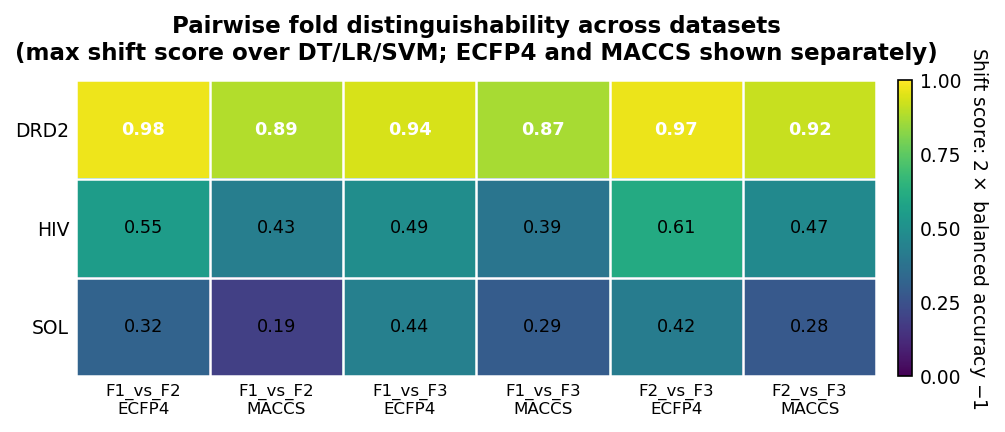

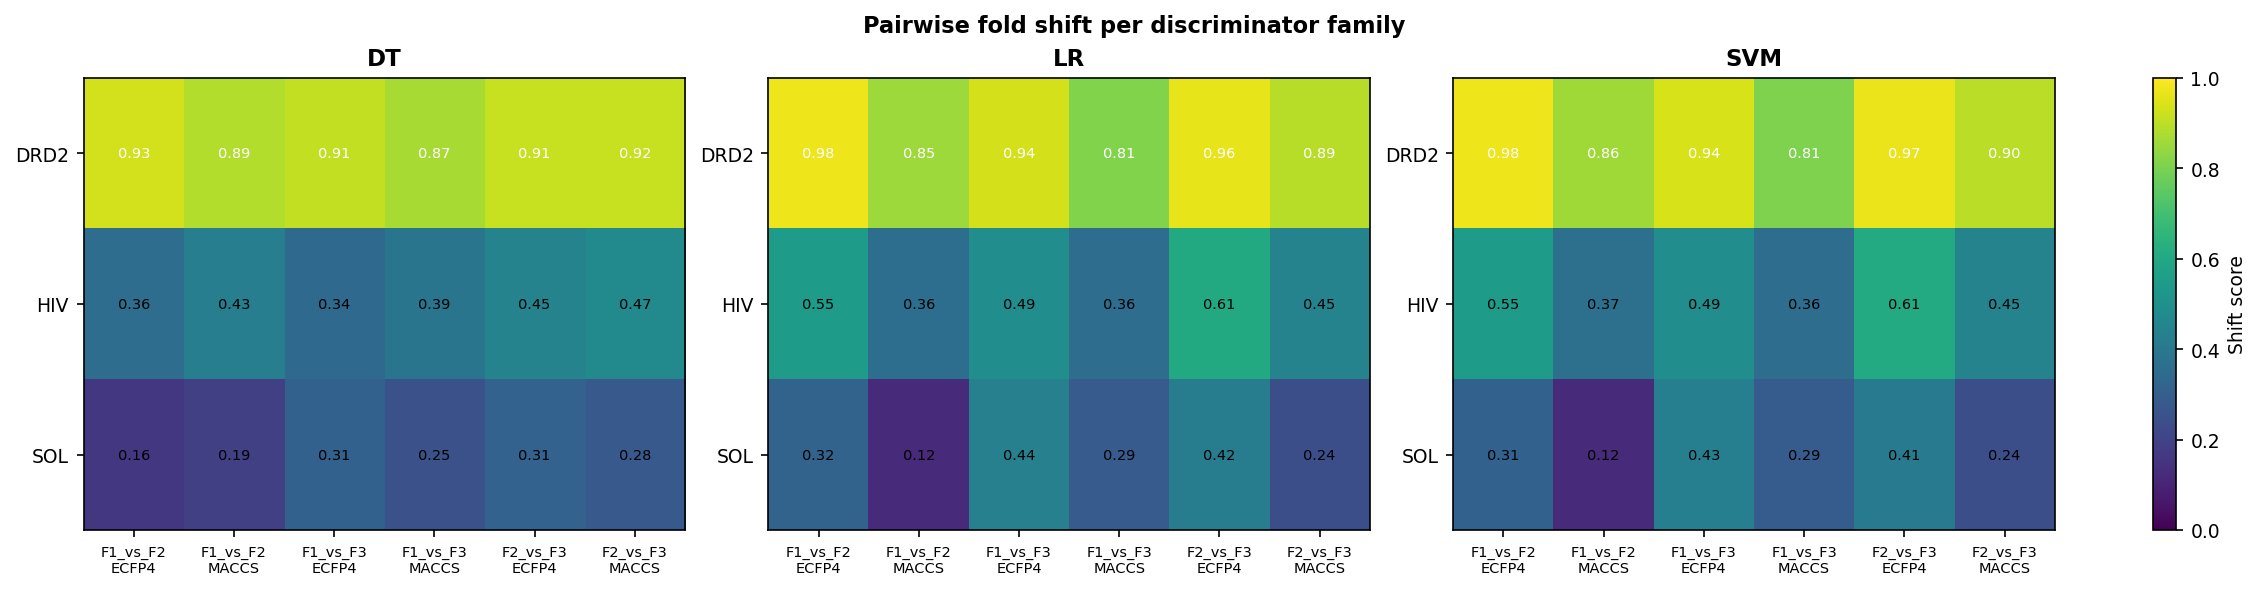

In [13]:
from textwrap import wrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global figure directory
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_FPS = ["ecfp4", "maccs"]

df_shift_plot = (
    df_search_cv
    .query("fingerprint in @PLOT_FPS")
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)
    .agg(
        shift_score_mean=("shift_score_01", "mean"),
        shift_score_max=("shift_score_01", "max"),
    )
)

SHIFT_AGG_COL = "shift_score_max"

df_shift_plot["column"] = (
    df_shift_plot["pair"] + "\n" + df_shift_plot["fingerprint"].str.upper()
)

shift_mat = (
    df_shift_plot
    .pivot(index="dataset", columns="column", values=SHIFT_AGG_COL)
    .reindex(DATASETS)
)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in shift_mat.columns:
            ordered_cols.append(col)

shift_mat = shift_mat[ordered_cols]

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

n_rows, n_cols = shift_mat.shape

fig_width = max(6.8, 1.0 * n_cols)
fig_height = max(2.6, 0.55 * n_rows + 1.3)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Mask missing values, if any
data = np.ma.masked_invalid(shift_mat.values.astype(float))

cmap = mpl.colormaps["viridis"].copy()
cmap.set_bad(color="lightgray")

im = ax.imshow(
    data,
    vmin=0,
    vmax=1,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Pairwise fold distinguishability across datasets\n"
    "(max shift score over DT/LR/SVM; ECFP4 and MACCS shown separately)",
    pad=10,
    fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(shift_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in shift_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    for j in range(n_cols):
        value = shift_mat.iloc[i, j]

        if pd.notna(value):
            text_color = "white" if value >= 0.62 else "black"

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=text_color,
                fontweight="bold" if value >= 0.80 else "normal",
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    r"Shift score: $2 \times$ balanced accuracy $- 1$",
    rotation=270,
    labelpad=14,
)

cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(length=0)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.pdf",
    bbox_inches="tight",
)

plt.show()

# Per-model shift heatmaps (one panel per discriminator family)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)

for ax, model_name in zip(axes, ["DT", "LR", "SVM"]):
    sub = (
        df_search_cv
        .query("fingerprint in @PLOT_FPS and model == @model_name")
        .groupby(["dataset", "pair", "fingerprint"], as_index=False)["shift_score_01"]
        .mean()
    )
    sub["column"] = sub["pair"] + "\n" + sub["fingerprint"].str.upper()
    mat = sub.pivot(index="dataset", columns="column", values="shift_score_01").reindex(DATASETS)
    mat = mat[[c for c in ordered_cols if c in mat.columns]]

    im = ax.imshow(
        np.ma.masked_invalid(mat.values.astype(float)),
        vmin=0, vmax=1, cmap=cmap, aspect="auto", interpolation="nearest",
    )
    ax.set_title(model_name, fontweight="bold")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=0, fontsize=7)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([d.upper() for d in mat.index])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if v >= 0.62 else "black")

fig.colorbar(im, ax=axes, fraction=0.02, label="Shift score")
fig.suptitle("Pairwise fold shift per discriminator family", fontweight="bold", y=1.05)
fig.savefig(FIG_ROOT / "shift_heatmap_per_model.png", dpi=600, bbox_inches="tight")
plt.show()

## Fold-Aware List A vs List B Feature Overlap

Lo shift coinvolge le stesse feature del modello di attività?

In [14]:


PLOT_FPS = ["ecfp4", "maccs"]
OVERLAP_K = 20
LISTB_SOURCE = "same_search_cv"

PAIR_TO_OUTER_FOLD = {
    "F1_vs_F2": 1,
    "F1_vs_F3": 2,
    "F2_vs_F3": 3,
}


def top_features_from_listB(
    df_b: pd.DataFrame,
    dataset: str,
    pair: str,
    model: str,
    fingerprint: str,
    source: str,
    k: int,
) -> set:
    """
    Top-k shift/discriminator features for one dataset-pair-model-fingerprint.
    """
    sub = df_b[
        (df_b["dataset"] == dataset)
        & (df_b["pair"] == pair)
        & (df_b["model"] == model)
        & (df_b["fingerprint"] == fingerprint)
        & (df_b["source"] == source)
    ].copy()

    if sub.empty:
        return set()

    sub = sub.sort_values("rank", ascending=True)

    return set(sub.head(k)["feature_idx"].astype(int))

def normalize_protocol_name(x: str) -> str:
    """
    Normalize protocol labels to the two protocol families used in this study.
    """
    x = str(x).strip().lower()

    if x in {"ood holdout", "ood_holdout", "holdout_ood"}:
        return "ood"

    if x in {"random shuffle", "random_shuffle", "random"}:
        return "random"

    if "ood" in x and "random" not in x:
        return "ood"

    if "random" in x:
        return "random"

    return x

def top_features_listA_by_protocol_and_fold(
    df_a: pd.DataFrame,
    dataset: str,
    model: str,
    fingerprint: str,
    protocol: str,
    fold: int,
    k: int,
) -> set:
    """
    Top-k activity features for one dataset-model-fingerprint-protocol-fold.

    This aligns List A with the same outer fold corresponding to the List B pair:
        F1_vs_F2 -> fold 1
        F1_vs_F3 -> fold 2
        F2_vs_F3 -> fold 3

    Protocol matching is exact after normalization.
    """
    work = df_a.copy()

    work["protocol_family"] = work["protocol"].map(normalize_protocol_name)
    target_protocol = normalize_protocol_name(protocol)

    sub = work[
        (work["dataset"] == dataset)
        & (work["model"] == model)
        & (work["fingerprint"] == fingerprint)
        & (work["protocol_family"] == target_protocol)
        & (work["fold"].astype(int) == int(fold))
    ].copy()

    if sub.empty:
        return set()

    agg = (
        sub.groupby("feature_idx", as_index=False)["activity_importance"]
        .mean()
        .sort_values("activity_importance", ascending=False)
    )

    return set(agg.head(k)["feature_idx"].astype(int))


overlap_rows = []

PROTOCOLS = ["OOD holdout", "Random shuffle"]

PROTOCOL_SHORT = {
    "OOD holdout": "ood",
    "Random shuffle": "random",
}

for dataset in DATASETS:
    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"
        outer_fold = PAIR_TO_OUTER_FOLD[pair_name]

        for fp in PLOT_FPS:
            for model in ["DT", "LR", "SVM"]:

                b_features = top_features_from_listB(
                    df_b=df_listB,
                    dataset=dataset,
                    pair=pair_name,
                    model=model,
                    fingerprint=fp,
                    source=LISTB_SOURCE,
                    k=OVERLAP_K,
                )

                if not b_features:
                    continue

                for protocol in PROTOCOLS:
                    a_features = top_features_listA_by_protocol_and_fold(
                        df_a=df_listA,
                        dataset=dataset,
                        model=model,
                        fingerprint=fp,
                        protocol=protocol,
                        fold=outer_fold,
                        k=OVERLAP_K,
                    )

                    if not a_features:
                        continue

                    common_features = a_features & b_features
                    overlap = len(common_features) / OVERLAP_K

                    overlap_rows.append({
                        "dataset": dataset,
                        "pair": pair_name,
                        "outer_fold": outer_fold,
                        "fingerprint": fp,
                        "model": model,
                        "activity_protocol": PROTOCOL_SHORT[protocol],
                        "k": OVERLAP_K,
                        "overlap": overlap,
                        "n_overlap": len(common_features),
                        "overlap_features": json.dumps(sorted(list(common_features))),
                    })

df_overlap = pd.DataFrame(overlap_rows)

df_overlap.to_csv(
    OUT_ROOT / f"cross_dataset_listA_listB_overlap_by_protocol_foldaware_top{OVERLAP_K}.csv",
    index=False,
)

display(df_overlap.head(12))

,dataset,pair,outer_fold,fingerprint,model,activity_protocol,k,overlap,n_overlap,overlap_features
0,drd2,F1_vs_F2,1,ecfp4,DT,ood,20,0.00,0,[]
1,drd2,F1_vs_F2,1,ecfp4,DT,random,20,0.00,0,[]
2,drd2,F1_vs_F2,1,ecfp4,LR,ood,20,0.00,0,[]
3,drd2,F1_vs_F2,1,ecfp4,LR,random,20,0.00,0,[]
4,drd2,F1_vs_F2,1,ecfp4,SVM,ood,20,0.05,1,[1480]
5,drd2,F1_vs_F2,1,ecfp4,SVM,random,20,0.00,0,[]
6,drd2,F1_vs_F2,1,maccs,DT,ood,20,0.10,2,"[82, 152]"
7,drd2,F1_vs_F2,1,maccs,DT,random,20,0.20,4,"[42, 79, 80, 104]"
8,drd2,F1_vs_F2,1,maccs,LR,ood,20,0.15,3,"[24, 85, 99]"
9,drd2,F1_vs_F2,1,maccs,LR,random,20,0.15,3,"[85, 99, 122]"


## 15. Feature-Overlap Heatmaps by Validation Protocol

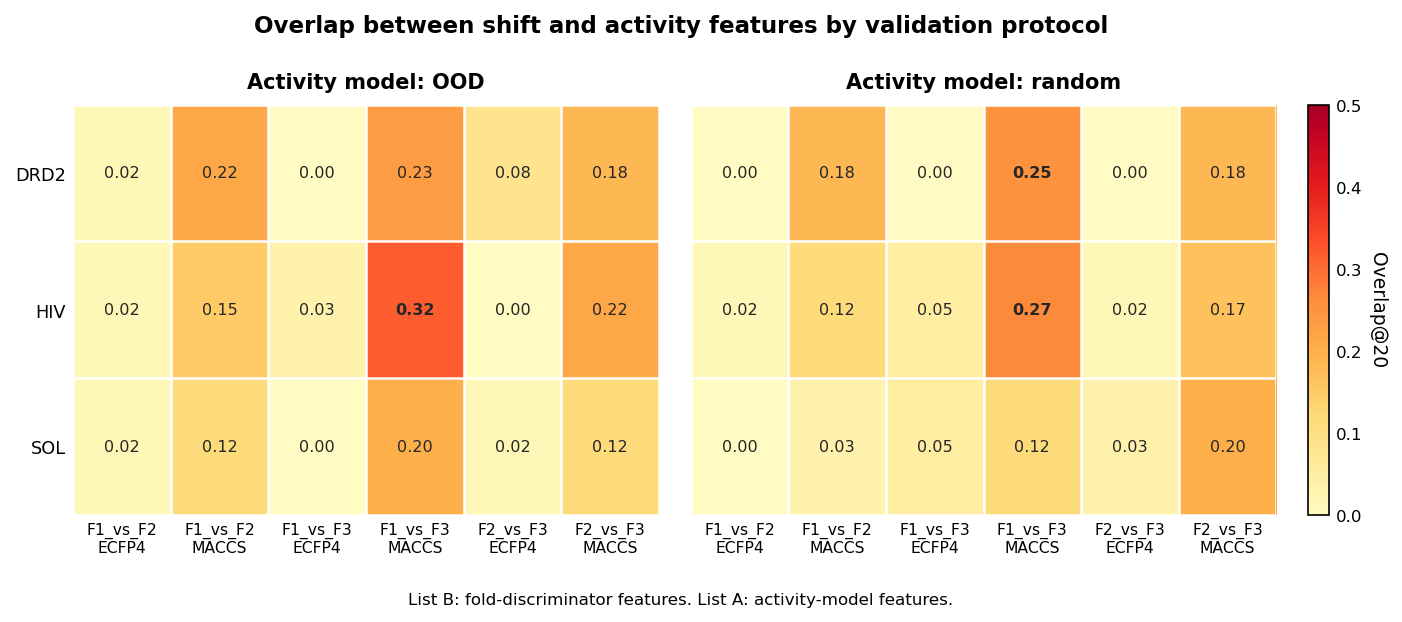

In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 8.5,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

base_cmap = mpl.colormaps["YlOrRd"]
colors = base_cmap(np.linspace(0.03, 0.92, 256))
cmap = mpl.colors.LinearSegmentedColormap.from_list("truncated_YlOrRd", colors)
cmap.set_bad(color="lightgray")

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        ordered_cols.append(f"{pair}\n{fp}")

protocol_labels = {
    "ood": "Activity model: OOD",
    "random": "Activity model: random",
}

vmin = 0.0
vmax = 0.50

fig = plt.figure(figsize=(10.8, 3.55))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.035],
    wspace=0.08,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
]

cax = fig.add_subplot(gs[0, 2])

last_im = None

for ax, protocol in zip(axes, ["ood", "random"]):
    sub = (
        df_overlap
        .query("activity_protocol == @protocol")
        .groupby(["dataset", "pair", "fingerprint"], as_index=False)["overlap"]
        .mean()
    )

    sub["column"] = (
        sub["pair"] + "\n" + sub["fingerprint"].str.upper()
    )

    mat = (
        sub
        .pivot(index="dataset", columns="column", values="overlap")
        .reindex(DATASETS)
    )

    mat = mat[[c for c in ordered_cols if c in mat.columns]]

    data = np.ma.masked_invalid(mat.values.astype(float))

    last_im = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(
        protocol_labels[protocol],
        fontweight="bold",
        pad=8,
    )

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=0, ha="center")

    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels([d.upper() for d in mat.index])

    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)

    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]

            if pd.notna(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7.7,
                    color="0.15",
                    fontweight="bold" if v >= 0.25 else "normal",
                )

axes[1].tick_params(labelleft=False)

cbar = fig.colorbar(
    last_im,
    cax=cax,
)

cbar.set_label(
    f"Overlap@{OVERLAP_K}",
    rotation=270,
    labelpad=12,
)

cbar.set_ticks(np.linspace(vmin, vmax, 6))
cbar.ax.tick_params(length=0, labelsize=8)

fig.suptitle(
    "Overlap between shift and activity features by validation protocol",
    fontweight="bold",
    y=1.05,
    fontsize=11,
)

fig.text(
    0.5,
    -0.035,
    "List B: fold-discriminator features. List A: activity-model features.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.savefig(
    FIG_ROOT / f"listA_listB_overlap_by_protocol_top{OVERLAP_K}_paper_final.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"listA_listB_overlap_by_protocol_top{OVERLAP_K}_paper_final.pdf",
    bbox_inches="tight",
)

plt.show()

## Global Feature-Overlap Heatmap

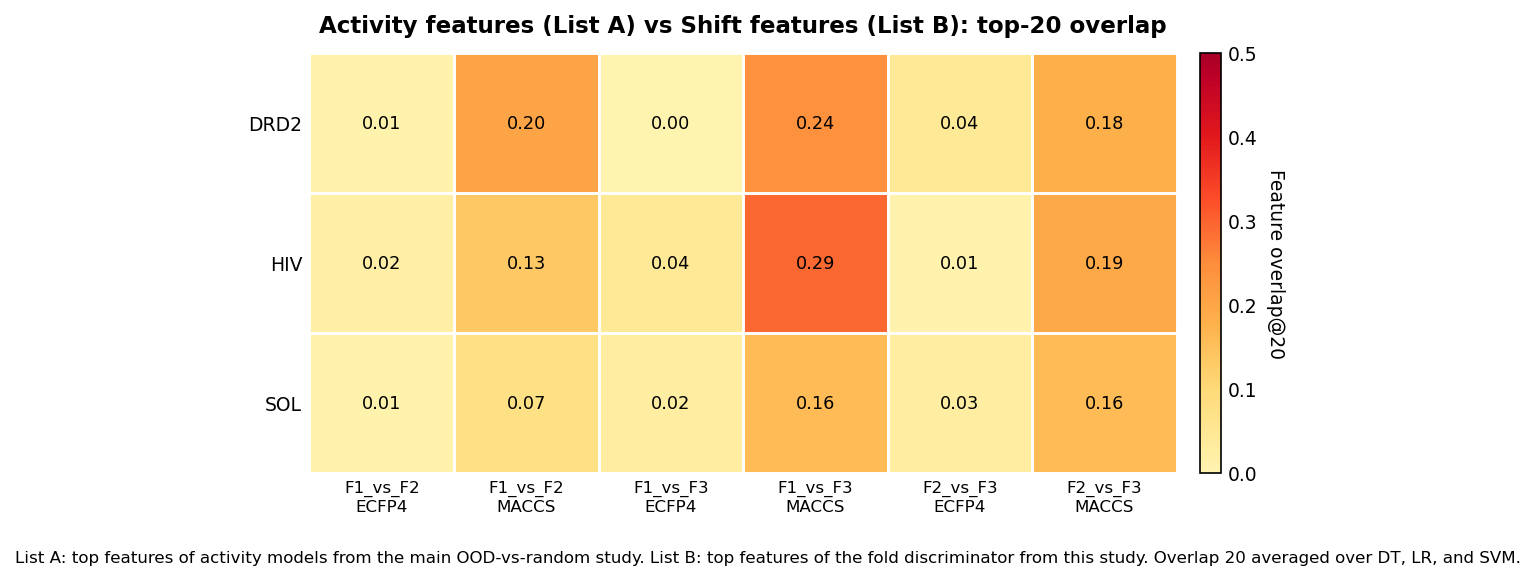

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

df_overlap_plot = (
    df_overlap
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)["overlap"]
    .mean()
)

df_overlap_plot["column"] = (
    df_overlap_plot["pair"] + "\n" + df_overlap_plot["fingerprint"].str.upper()
)

overlap_mat = (
    df_overlap_plot
    .pivot(index="dataset", columns="column", values="overlap")
    .reindex(DATASETS)
)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in overlap_mat.columns:
            ordered_cols.append(col)

overlap_mat = overlap_mat[ordered_cols]

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

n_rows, n_cols = overlap_mat.shape

fig, ax = plt.subplots(figsize=(7.2, 3.6))

data = np.ma.masked_invalid(overlap_mat.values.astype(float))

base_cmap = mpl.colormaps["YlOrRd"]
colors = base_cmap(np.linspace(0.08, 0.92, 256))
cmap = mpl.colors.LinearSegmentedColormap.from_list("truncated_YlOrRd", colors)
cmap.set_bad(color="lightgray")

vmax = 0.50

im = ax.imshow(
    data,
    vmin=0,
    vmax=vmax,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Activity features (List A) vs Shift features (List B): top-20 overlap",
    pad=10, fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(overlap_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in overlap_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    for j in range(n_cols):
        value = overlap_mat.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="black",
                fontweight="bold" if value >= 0.30 else "normal",
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    f"Feature overlap@{OVERLAP_K}",
    rotation=270,
    labelpad=13,
)

cbar.set_ticks(np.linspace(0, vmax, 6))
cbar.ax.tick_params(length=0)

fig.text(
    0.5, -0.03,
    "List A: top features of activity models from the main OOD-vs-random study. "
    "List B: top features of the fold discriminator from this study. "
    f"Overlap {OVERLAP_K} averaged over DT, LR, and SVM.",
    ha="center", va="top", fontsize=8,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.pdf",
    bbox_inches="tight",
)

plt.show()

## Load OOD-vs-Random Per-Fold Protocol Results



In [17]:
OOD_CROSS_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / TASK
    / "cross_dataset"
)

PROTOCOL_PATH = OOD_CROSS_DIR / "cross_dataset_protocol_per_fold.csv"

if not PROTOCOL_PATH.exists():
    raise FileNotFoundError(
        f"Missing protocol table from OOD-vs-random study: {PROTOCOL_PATH}"
    )

df_protocol_per_fold = pd.read_csv(PROTOCOL_PATH).copy()
df_protocol_per_fold = df_protocol_per_fold[
    df_protocol_per_fold["dataset"].isin(DATASETS_MAIN)
].copy()

assert "kdr" not in set(df_protocol_per_fold["dataset"]), (
    "KDR should not enter the main shift-vs-protocol analysis."
)

print("protocol_per_fold columns:")
print(df_protocol_per_fold.columns.tolist())

display(df_protocol_per_fold.head())

protocol_per_fold columns:
['dataset', 'dataset_label', 'model', 'model_short', 'fingerprint', 'protocol', 'fold', 'inner_pr_auc', 'inner_train_pr_auc', 'train_pr_auc', 'test_pr_auc', 'inner_test_gap', 'train_test_gap', 'dataset_order', 'model_order', 'fingerprint_order', 'protocol_order']


,dataset,dataset_label,model,model_short,fingerprint,protocol,fold,inner_pr_auc,inner_train_pr_auc,train_pr_auc,test_pr_auc,inner_test_gap,train_test_gap,dataset_order,model_order,fingerprint_order,protocol_order
0,drd2,DRD2,Decision Tree,DT,ECFP4,OOD holdout,1,0.849198,0.931822,0.9496,0.6620,0.187198,0.2876,0,0,0,0
1,drd2,DRD2,Decision Tree,DT,ECFP4,OOD holdout,2,0.697409,0.882575,0.7683,0.8022,-0.104791,-0.0339,0,0,0,0
2,drd2,DRD2,Decision Tree,DT,ECFP4,OOD holdout,3,0.731996,0.945777,0.9029,0.7052,0.026796,0.1977,0,0,0,0
3,drd2,DRD2,Decision Tree,DT,ECFP4,Random shuffle,1,0.906735,0.955275,0.9339,0.6687,0.238035,0.2652,0,0,0,1
4,drd2,DRD2,Decision Tree,DT,ECFP4,Random shuffle,2,0.830900,0.931783,0.8539,0.7398,0.091100,0.1141,0,0,0,1


## Pairwise Shift vs OOD-vs-Random Protocol Gap

In [18]:
def infer_fold_column(df: pd.DataFrame) -> str:
    candidates = ["fold", "outer_fold", "fold_id", "test_fold"]

    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(
        "Could not infer fold column. "
        f"Available columns: {df.columns.tolist()}"
    )

In [19]:
# Pairwise shift vs OOD-vs-random validation gap
#
# Two complementary gaps, both built from protocol_per_fold.csv:
#
# 1. optimism_gap_diff:
#       optimism_gap_random  =  inner_pr_auc_random  - test_pr_auc_random
#       optimism_gap_ood     =  inner_pr_auc_ood     - test_pr_auc_ood
#       optimism_gap_diff    =  optimism_gap_random  - optimism_gap_ood
#    Positive value: random validation is more optimistic than OOD validation.
#
# 2. test_gap:
#       test_gap = test_pr_auc_ood - test_pr_auc_random
#    Positive value: OOD-selected model beats random-selected model on the real OOD test set.
# ============================================================

PLOT_FPS = ["ecfp4", "maccs"]

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}

# Shift table (averaged over fingerprints and models for the overview)
df_shift_pair = (
    df_search_cv
    .query("fingerprint in @PLOT_FPS")
    .loc[lambda d: d["dataset"].isin(DATASETS_MAIN)]
    .groupby(["dataset", "pair"], as_index=False)
    .agg(
        shift_score_mean=("shift_score_01", "mean"),
        shift_score_max=("shift_score_01", "max"),
    )
)

# Main x-axis score: best discriminator across model/fingerprint combinations.
df_shift_pair["shift_score_01"] = df_shift_pair["shift_score_max"]

# Build the per-fold protocol table
df_gap_raw = df_protocol_per_fold.copy()
df_gap_raw["fingerprint_norm"] = df_gap_raw["fingerprint"].astype(str).str.lower()
df_gap_raw["model_short_norm"] = df_gap_raw["model_short"].astype(str).str.upper()

df_gap_raw = df_gap_raw[
    df_gap_raw["fingerprint_norm"].isin(PLOT_FPS)
    & df_gap_raw["model_short_norm"].isin(["DT", "LR", "SVM"])
].copy()
df_gap_raw["protocol_norm"] = df_gap_raw["protocol"].astype(str).str.lower()

def protocol_family(x: str) -> str:
    if "random" in x:
        return "random"
    if "ood" in x or "holdout" in x:
        return "ood"
    return x

df_gap_raw["protocol_family"] = df_gap_raw["protocol_norm"].map(protocol_family)
df_gap_raw = df_gap_raw[df_gap_raw["protocol_family"].isin(["random", "ood"])].copy()

df_gap_raw["outer_fold"] = df_gap_raw["fold"].astype(int)
df_gap_raw["pair"] = df_gap_raw["outer_fold"].map(OUTER_FOLD_TO_PAIR)

# Per-fold optimism gap, per protocol
df_gap_raw["optimism_gap"] = df_gap_raw["inner_pr_auc"] - df_gap_raw["test_pr_auc"]

df_gap_agg = (
    df_gap_raw
    .groupby(["dataset", "pair", "protocol_family"], as_index=False)
    .agg(
        inner_pr_auc=("inner_pr_auc", "mean"),
        test_pr_auc=("test_pr_auc", "mean"),
        optimism_gap=("optimism_gap", "mean"),
    )
)

# Pivot random vs OOD
df_gap_pivot = df_gap_agg.pivot_table(
    index=["dataset", "pair"],
    columns="protocol_family",
    values=["inner_pr_auc", "test_pr_auc", "optimism_gap"],
).reset_index()

df_gap_pivot.columns = [
    "_".join(c).rstrip("_") if isinstance(c, tuple) else c
    for c in df_gap_pivot.columns
]

df_gap_pivot["optimism_gap_diff"] = (
    df_gap_pivot["optimism_gap_random"] - df_gap_pivot["optimism_gap_ood"]
)
df_gap_pivot["test_gap"] = (
    df_gap_pivot["test_pr_auc_ood"] - df_gap_pivot["test_pr_auc_random"]
)

df_gap_pair = df_gap_pivot[[
    "dataset", "pair",
    "inner_pr_auc_random", "inner_pr_auc_ood",
    "test_pr_auc_random",  "test_pr_auc_ood",
    "optimism_gap_random", "optimism_gap_ood",
    "optimism_gap_diff",
    "test_gap",
]].copy()

df_shift_gap = df_shift_pair.merge(df_gap_pair, on=["dataset", "pair"], how="inner")

df_shift_gap = df_shift_gap[df_shift_gap["dataset"].isin(DATASETS_MAIN)].copy()

assert "kdr" not in set(df_shift_gap["dataset"]), (
    "KDR should not enter the main shift-vs-protocol analysis."
)

expected_pairs = pd.MultiIndex.from_product(
    [DATASETS_MAIN, [f"{a}_vs_{b}" for a, b in PAIRS]],
    names=["dataset", "pair"],
).to_frame(index=False)

observed_pairs = df_shift_gap[["dataset", "pair"]].drop_duplicates()

missing_pairs = (
    expected_pairs
    .merge(observed_pairs, on=["dataset", "pair"], how="left", indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

if len(missing_pairs) > 0:
    raise ValueError(
        "Missing dataset/pair rows in df_shift_gap:\n"
        + missing_pairs.to_string(index=False)
    )

if len(df_shift_gap) != len(expected_pairs):
    print(
        f"WARNING: expected {len(expected_pairs)} dataset/pair rows, "
        f"got {len(df_shift_gap)}. There may be duplicated rows."
    )

df_shift_gap.to_csv(
    OUT_ROOT / "cross_dataset_pairwise_shift_vs_protocol_gap.csv",
    index=False,
)

display(df_shift_gap.round(3))

,dataset,pair,shift_score_mean,shift_score_max,shift_score_01,inner_pr_auc_random,inner_pr_auc_ood,test_pr_auc_random,test_pr_auc_ood,optimism_gap_random,optimism_gap_ood,optimism_gap_diff,test_gap
0,drd2,F1_vs_F2,0.913,0.977,0.977,0.904,0.834,0.648,0.652,0.257,0.182,0.075,0.005
1,drd2,F1_vs_F3,0.879,0.941,0.941,0.851,0.698,0.804,0.806,0.047,-0.108,0.155,0.002
2,drd2,F2_vs_F3,0.926,0.971,0.971,0.879,0.719,0.750,0.735,0.128,-0.016,0.144,-0.016
3,hiv,F1_vs_F2,0.437,0.554,0.554,0.298,0.114,0.127,0.112,0.171,0.002,0.169,-0.015
4,hiv,F1_vs_F3,0.404,0.492,0.492,0.297,0.175,0.074,0.081,0.224,0.094,0.130,0.008
5,hiv,F2_vs_F3,0.506,0.610,0.610,0.394,0.162,0.033,0.033,0.361,0.129,0.232,-0.000
6,sol,F1_vs_F2,0.203,0.318,0.318,0.502,0.446,0.452,0.455,0.050,-0.009,0.058,0.002
7,sol,F1_vs_F3,0.334,0.436,0.436,0.520,0.468,0.451,0.445,0.070,0.023,0.046,-0.006
8,sol,F2_vs_F3,0.317,0.419,0.419,0.524,0.461,0.416,0.428,0.108,0.033,0.075,0.012


## Scatter Plot: Shift Score vs OOD Test Benefit

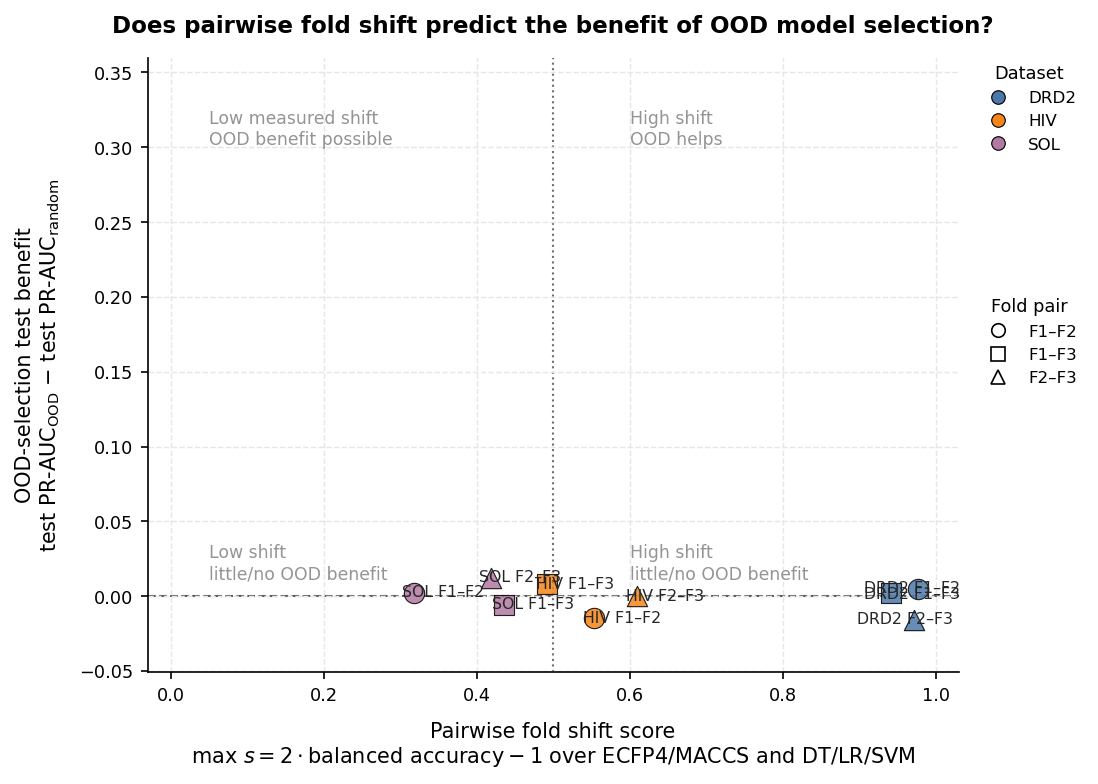

In [20]:
# Plot: pairwise fold shift vs OOD-selection test benefit

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from adjustText import adjust_text

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

df_shift_gap = df_shift_gap[df_shift_gap["dataset"].isin(DATASETS_MAIN)].copy()

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

# Positive value = OOD-based model selection improves final OOD test PR-AUC.
GAP_COL = "test_gap"

GAP_LABEL = (
    "OOD-selection test benefit\n"
    r"test PR-AUC$_{\mathrm{OOD}}$ $-$ test PR-AUC$_{\mathrm{random}}$"
)

SHIFT_THRESHOLD = 0.50

markers = {
    "F1_vs_F2": "o",
    "F1_vs_F3": "s",
    "F2_vs_F3": "^",
}

dataset_colors = {
    "DRD2": "#4C78A8",
    "HIV":  "#F58518",
    "SOL":  "#B279A2",
}

fig, ax = plt.subplots(figsize=(7.4, 5.3))

texts = []

for _, row in df_shift_gap.iterrows():
    dataset = row["dataset"].upper()
    pair = row["pair"]

    x = row["shift_score_01"]
    y = row[GAP_COL]

    ax.scatter(
        x,
        y,
        s=95,
        marker=markers.get(pair, "o"),
        facecolor=dataset_colors.get(dataset, "gray"),
        edgecolor="black",
        linewidth=0.55,
        alpha=0.85,
        zorder=3,
    )

    texts.append(
        ax.text(
            x,
            y,
            f"{dataset} {pair.replace('_vs_', '–')}",
            fontsize=7.6,
            color="0.15",
            zorder=4,
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.25),
    force_text=(0.25, 0.35),
    force_static=(0.15, 0.25),
    only_move={"text": "xy"},
)

ax.axhline(
    0.0,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    alpha=0.85,
    zorder=1,
)

ax.axvline(
    SHIFT_THRESHOLD,
    color="0.25",
    linestyle=":",
    linewidth=1.0,
    alpha=0.75,
    zorder=1,
)

ax.set_xlim(-0.03, 1.03)

y_min = min(-0.04, df_shift_gap[GAP_COL].min() - 0.035)
y_max = max(0.36, df_shift_gap[GAP_COL].max() + 0.035)
ax.set_ylim(y_min, y_max)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    color="0.90",
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

quad_style = dict(
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.text(
    0.05,
    y_max - 0.035,
    "Low measured shift\nOOD benefit possible",
    **quad_style,
)

ax.text(
    0.60,
    y_max - 0.035,
    "High shift\nOOD helps",
    **quad_style,
)

ax.text(
    0.60,
    0.035,
    "High shift\nlittle/no OOD benefit",
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.text(
    0.05,
    0.035,
    "Low shift\nlittle/no OOD benefit",
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.set_xlabel(
    "Pairwise fold shift score\n"
    r"max $s = 2 \cdot \mathrm{balanced\ accuracy} - 1$ over ECFP4/MACCS and DT/LR/SVM",
    labelpad=8,
)

ax.set_ylabel(GAP_LABEL, labelpad=8)

ax.set_title(
    "Does pairwise fold shift predict the benefit of OOD model selection?",
    pad=12,
    fontweight="bold",
)

dataset_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.55,
        markersize=6.5,
        label=dataset,
    )
    for dataset, color in dataset_colors.items()
]

pair_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=6.5,
        label=pair.replace("_vs_", "–"),
    )
    for pair, marker in markers.items()
]

legend_1 = ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0.0,
)

ax.add_artist(legend_1)

ax.legend(
    handles=pair_handles,
    title="Fold pair",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.62),
    frameon=False,
    borderaxespad=0.0,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / "pairwise_shift_vs_test_gap_quadrants_paper.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "pairwise_shift_vs_test_gap_quadrants_paper.pdf",
    bbox_inches="tight",
)

plt.show()

##  Predictive-shift overlap vs OOD validation usefulness

 Question:
   Does OOD validation help more when the fold shift affects the same
   features used by the activity model?

Descriptive pair-level correlations (n=9; dataset × fold-pair points):
  Pearson  = -0.370
  Spearman = 0.042
These are descriptive only; n is too small for statistical claims.


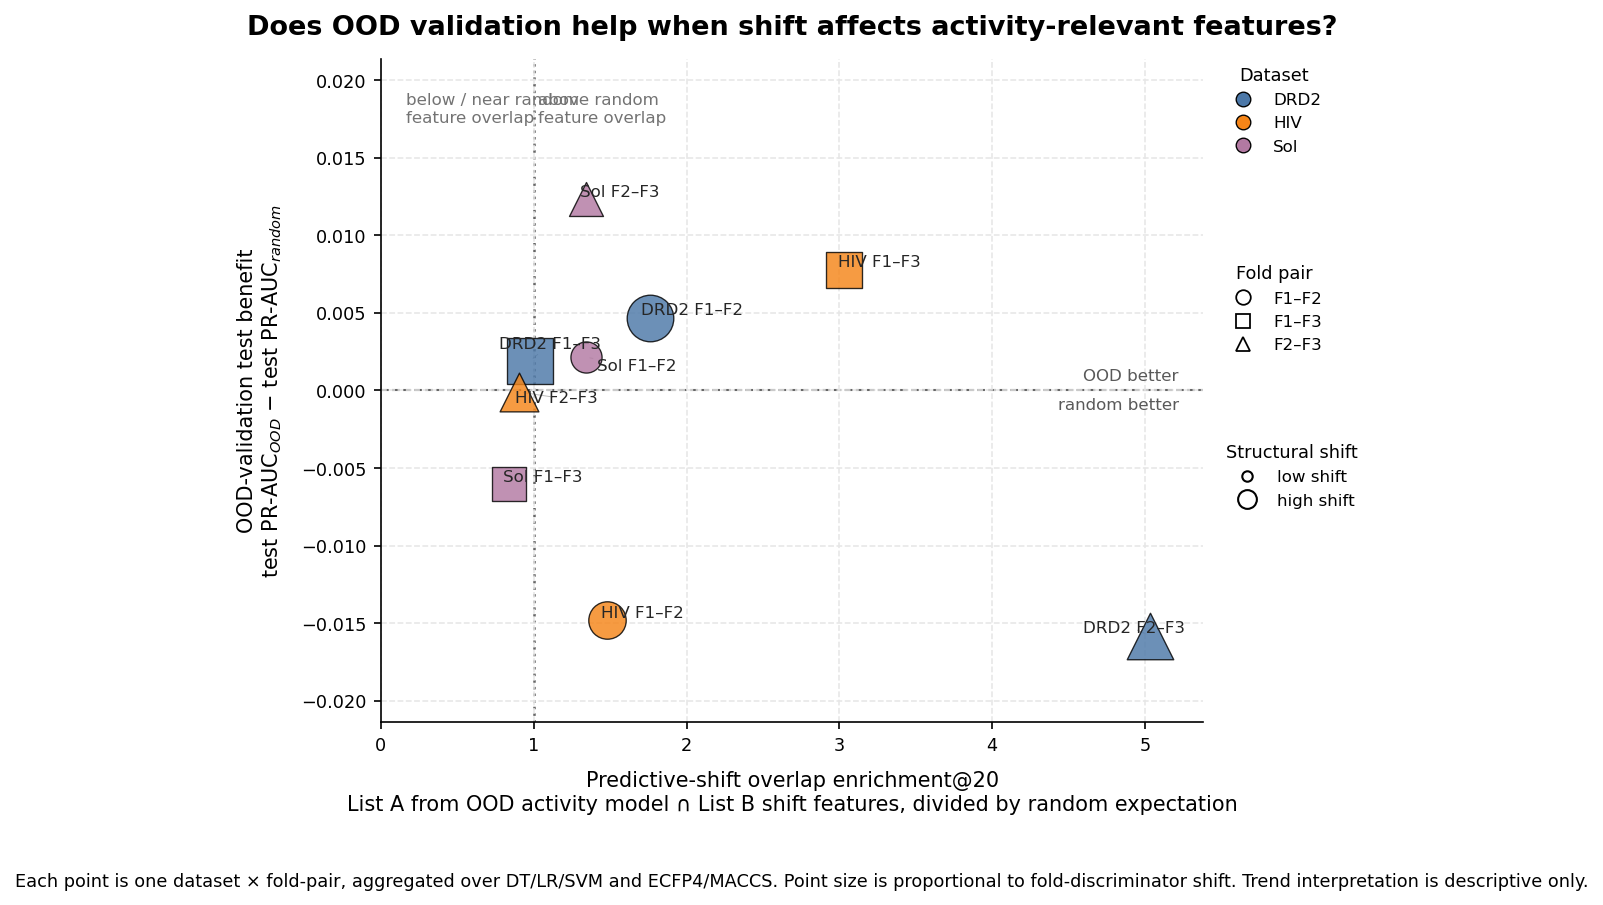

In [21]:
# ============================================================
# Predictive-shift overlap vs OOD validation usefulness
#
# Question:
# Does OOD validation help more when the fold shift affects the same
# features used by the activity model?
#
# Main plot:
#   x = enrichment of List A / List B overlap over random expectation
#       using List A from the OOD-selected activity model
#
#   y = OOD-selection test benefit
#       test_PR_AUC_OOD - test_PR_AUC_random
#
# Each point:
#   one dataset × fold-pair, aggregated over DT/LR/SVM and ECFP4/MACCS.
#
# Interpretation:
#   x > 1  -> activity features overlap with shift features more than expected by chance
#   y > 0  -> OOD validation improves final OOD test PR-AUC
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_FPS = ["ecfp4", "maccs"]
PLOT_MODELS = ["DT", "LR", "SVM"]

OVERLAP_K = 20

FP_N_FEATURES = {
    "ecfp4": 2048,
    "maccs": 167,
}

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}

PAIR_LABELS = {
    "F1_vs_F2": "F1–F2",
    "F1_vs_F3": "F1–F3",
    "F2_vs_F3": "F2–F3",
}

DATASET_COLORS = {
    "drd2": "#4C78A8",
    "hiv": "#F58518",
    "sol": "#B279A2",
}

PAIR_MARKERS = {
    "F1_vs_F2": "o",
    "F1_vs_F3": "s",
    "F2_vs_F3": "^",
}


def _protocol_family(x):
    x = str(x).strip().lower()

    if "random" in x:
        return "random"

    if "ood" in x or "holdout" in x:
        return "ood"

    return x


# ------------------------------------------------------------
# 1. Build List A / List B overlap enrichment table
# ------------------------------------------------------------

ov = df_overlap.copy()

ov = ov[
    ov["dataset"].isin(DATASETS_MAIN)
    & ov["fingerprint"].isin(PLOT_FPS)
    & ov["model"].isin(PLOT_MODELS)
    & (ov["k"].astype(int) == int(OVERLAP_K))
].copy()

ov["fingerprint_norm"] = ov["fingerprint"].astype(str).str.lower()
ov["model_norm"] = ov["model"].astype(str).str.upper()
ov["activity_protocol_norm"] = ov["activity_protocol"].astype(str).str.lower()

ov_pivot = (
    ov
    .pivot_table(
        index=["dataset", "pair", "fingerprint_norm", "model_norm"],
        columns="activity_protocol_norm",
        values="overlap",
        aggfunc="mean",
    )
    .reset_index()
)

if "ood" not in ov_pivot.columns:
    ov_pivot["ood"] = np.nan

if "random" not in ov_pivot.columns:
    ov_pivot["random"] = np.nan

ov_pivot = ov_pivot.rename(
    columns={
        "ood": "overlap_ood",
        "random": "overlap_random",
    }
)

ov_pivot["n_features"] = ov_pivot["fingerprint_norm"].map(FP_N_FEATURES)

if ov_pivot["n_features"].isna().any():
    missing_fps = sorted(
        ov_pivot.loc[ov_pivot["n_features"].isna(), "fingerprint_norm"].unique()
    )
    raise ValueError(f"Missing fingerprint sizes for: {missing_fps}")

# Since overlap = |A_k ∩ B_k| / k, random expected overlap is k / N.
ov_pivot["random_expected_overlap"] = OVERLAP_K / ov_pivot["n_features"]

ov_pivot["overlap_ood_enrichment"] = (
    ov_pivot["overlap_ood"] / ov_pivot["random_expected_overlap"]
)

ov_pivot["overlap_random_enrichment"] = (
    ov_pivot["overlap_random"] / ov_pivot["random_expected_overlap"]
)

ov_pivot["overlap_mean"] = ov_pivot[["overlap_ood", "overlap_random"]].mean(
    axis=1,
    skipna=True,
)

ov_pivot["overlap_mean_enrichment"] = (
    ov_pivot["overlap_mean"] / ov_pivot["random_expected_overlap"]
)

ov_pivot["n_overlap_protocols"] = (
    ov_pivot[["overlap_ood", "overlap_random"]]
    .notna()
    .sum(axis=1)
)

if (ov_pivot["n_overlap_protocols"] < 2).any():
    print(
        "WARNING: some model/fingerprint rows have overlap for only one activity protocol."
    )
    display(
        ov_pivot.loc[
            ov_pivot["n_overlap_protocols"] < 2,
            [
                "dataset",
                "pair",
                "fingerprint_norm",
                "model_norm",
                "overlap_ood",
                "overlap_random",
            ],
        ].head(20)
    )


# ------------------------------------------------------------
# 2. Build model/fingerprint-level OOD test benefit table
# ------------------------------------------------------------

gap = df_protocol_per_fold.copy()

gap = gap[gap["dataset"].isin(DATASETS_MAIN)].copy()

gap["fingerprint_norm"] = gap["fingerprint"].astype(str).str.lower()
gap["model_norm"] = gap["model_short"].astype(str).str.upper()

gap = gap[
    gap["fingerprint_norm"].isin(PLOT_FPS)
    & gap["model_norm"].isin(PLOT_MODELS)
].copy()

gap["protocol_family"] = gap["protocol"].map(_protocol_family)
gap = gap[gap["protocol_family"].isin(["ood", "random"])].copy()

gap["outer_fold"] = gap["fold"].astype(int)
gap["pair"] = gap["outer_fold"].map(OUTER_FOLD_TO_PAIR)

if gap["pair"].isna().any():
    bad_folds = sorted(gap.loc[gap["pair"].isna(), "outer_fold"].unique())
    raise ValueError(f"Could not map these outer folds to fold pairs: {bad_folds}")

gap["optimism_gap"] = gap["inner_pr_auc"] - gap["test_pr_auc"]

gap_agg = (
    gap
    .groupby(
        ["dataset", "pair", "fingerprint_norm", "model_norm", "protocol_family"],
        as_index=False,
    )
    .agg(
        inner_pr_auc=("inner_pr_auc", "mean"),
        test_pr_auc=("test_pr_auc", "mean"),
        optimism_gap=("optimism_gap", "mean"),
    )
)

gap_pivot = (
    gap_agg
    .pivot_table(
        index=["dataset", "pair", "fingerprint_norm", "model_norm"],
        columns="protocol_family",
        values=["inner_pr_auc", "test_pr_auc", "optimism_gap"],
        aggfunc="mean",
    )
    .reset_index()
)

gap_pivot.columns = [
    "_".join(c).rstrip("_") if isinstance(c, tuple) else c
    for c in gap_pivot.columns
]

required_gap_cols = [
    "test_pr_auc_ood",
    "test_pr_auc_random",
    "optimism_gap_ood",
    "optimism_gap_random",
]

missing_gap_cols = [c for c in required_gap_cols if c not in gap_pivot.columns]

if missing_gap_cols:
    raise ValueError(f"Missing required protocol columns: {missing_gap_cols}")

gap_pivot["test_benefit"] = (
    gap_pivot["test_pr_auc_ood"] - gap_pivot["test_pr_auc_random"]
)

gap_pivot["optimism_reduction"] = (
    gap_pivot["optimism_gap_random"] - gap_pivot["optimism_gap_ood"]
)


# ------------------------------------------------------------
# 3. Add structural shift score for each model/fingerprint row
# ------------------------------------------------------------

shift_mfp = df_search_cv.copy()

shift_mfp = shift_mfp[
    shift_mfp["dataset"].isin(DATASETS_MAIN)
    & shift_mfp["fingerprint"].isin(PLOT_FPS)
    & shift_mfp["model"].isin(PLOT_MODELS)
].copy()

shift_mfp["fingerprint_norm"] = shift_mfp["fingerprint"].astype(str).str.lower()
shift_mfp["model_norm"] = shift_mfp["model"].astype(str).str.upper()

shift_mfp = (
    shift_mfp
    .groupby(["dataset", "pair", "fingerprint_norm", "model_norm"], as_index=False)
    .agg(
        shift_score=("shift_score_01", "mean"),
        proxy_A_distance=("proxy_A_distance", "mean"),
    )
)


# ------------------------------------------------------------
# 4. Merge into one granular table
# ------------------------------------------------------------

predictive_shift_granular = (
    ov_pivot
    .merge(
        gap_pivot,
        on=["dataset", "pair", "fingerprint_norm", "model_norm"],
        how="inner",
    )
    .merge(
        shift_mfp,
        on=["dataset", "pair", "fingerprint_norm", "model_norm"],
        how="left",
    )
)

if len(predictive_shift_granular) == 0:
    raise ValueError(
        "No rows after merging overlap, protocol gap, and shift score tables."
    )

predictive_shift_granular.to_csv(
    OUT_ROOT / f"predictive_shift_overlap_granular_top{OVERLAP_K}.csv",
    index=False,
)


# ------------------------------------------------------------
# 5. Aggregate to dataset × fold-pair for a clean main plot
# ------------------------------------------------------------

plot_df = (
    predictive_shift_granular
    .groupby(["dataset", "pair"], as_index=False)
    .agg(
        overlap_ood_mean=("overlap_ood", "mean"),
        overlap_ood_enrichment_mean=("overlap_ood_enrichment", "mean"),
        overlap_mean=("overlap_mean", "mean"),
        overlap_mean_enrichment_mean=("overlap_mean_enrichment", "mean"),
        test_benefit_mean=("test_benefit", "mean"),
        optimism_reduction_mean=("optimism_reduction", "mean"),
        shift_score_mean=("shift_score", "mean"),
        shift_score_max=("shift_score", "max"),
        n_rows=("test_benefit", "size"),
    )
)

plot_df["dataset_label"] = plot_df["dataset"].map(DATASET_LABELS).fillna(
    plot_df["dataset"]
)

plot_df["pair_label"] = plot_df["pair"].map(PAIR_LABELS).fillna(plot_df["pair"])

plot_df.to_csv(
    OUT_ROOT / f"predictive_shift_overlap_pair_summary_top{OVERLAP_K}.csv",
    index=False,
)


# ------------------------------------------------------------
# 6. Descriptive correlations
# ------------------------------------------------------------

corr_df = plot_df.dropna(
    subset=["overlap_ood_enrichment_mean", "test_benefit_mean"]
).copy()

if len(corr_df) >= 3:
    pearson_corr = corr_df["overlap_ood_enrichment_mean"].corr(
        corr_df["test_benefit_mean"],
        method="pearson",
    )
    spearman_corr = corr_df["overlap_ood_enrichment_mean"].corr(
        corr_df["test_benefit_mean"],
        method="spearman",
    )
else:
    pearson_corr = np.nan
    spearman_corr = np.nan

print(
    "Descriptive pair-level correlations "
    f"(n={len(corr_df)}; dataset × fold-pair points):\n"
    f"  Pearson  = {pearson_corr:.3f}\n"
    f"  Spearman = {spearman_corr:.3f}\n"
    "These are descriptive only; n is too small for statistical claims."
)


# ------------------------------------------------------------
# 7. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.8, 5.6))

x_col = "overlap_ood_enrichment_mean"
y_col = "test_benefit_mean"

finite = plot_df.dropna(subset=[x_col, y_col]).copy()

if len(finite) == 0:
    raise ValueError("No finite rows available for plotting.")

x_min = min(0.0, finite[x_col].min() - 0.25)
x_max = finite[x_col].max() + 0.35

y_abs = max(
    abs(finite[y_col].min()),
    abs(finite[y_col].max()),
    0.01,
)

y_lim = 1.35 * y_abs

ax.axhline(
    0.0,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    alpha=0.8,
    zorder=1,
)

ax.axvline(
    1.0,
    color="0.25",
    linestyle=":",
    linewidth=1.2,
    alpha=0.8,
    zorder=1,
)

texts = []

for _, row in finite.iterrows():
    dataset = row["dataset"]
    pair = row["pair"]

    size = 90 + 420 * float(row["shift_score_max"])

    ax.scatter(
        row[x_col],
        row[y_col],
        s=size,
        marker=PAIR_MARKERS.get(pair, "o"),
        facecolor=DATASET_COLORS.get(dataset, "gray"),
        edgecolor="black",
        linewidth=0.65,
        alpha=0.82,
        zorder=3,
    )

    texts.append(
        ax.text(
            row[x_col],
            row[y_col],
            f"{row['dataset_label']} {row['pair_label']}",
            fontsize=8,
            color="0.15",
            zorder=4,
        )
    )

try:
    from adjustText import adjust_text

    adjust_text(
        texts,
        ax=ax,
        expand=(1.15, 1.25),
        force_text=(0.30, 0.35),
        force_static=(0.15, 0.20),
        arrowprops=dict(
            arrowstyle="-",
            color="0.55",
            lw=0.45,
            alpha=0.60,
        ),
    )
except ImportError:
    print("adjustText not installed; labels may overlap. Install with: pip install adjustText")

ax.set_xlim(x_min, x_max)
ax.set_ylim(-y_lim, y_lim)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.75,
    color="0.90",
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel(
    "Predictive-shift overlap enrichment@20\n"
    "List A from OOD activity model ∩ List B shift features, divided by random expectation",
    fontsize=10,
    labelpad=8,
)

ax.set_ylabel(
    "OOD-validation test benefit\n"
    r"test PR-AUC$_{OOD}$ $-$ test PR-AUC$_{random}$",
    fontsize=10,
    labelpad=8,
)

ax.set_title(
    "Does OOD validation help when shift affects activity-relevant features?",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.text(
    1.03,
    y_lim * 0.90,
    "above random\nfeature overlap",
    fontsize=8,
    color="0.45",
    ha="left",
    va="top",
)

ax.text(
    x_min + 0.03 * (x_max - x_min),
    y_lim * 0.90,
    "below / near random\nfeature overlap",
    fontsize=8,
    color="0.45",
    ha="left",
    va="top",
)

ax.text(
    x_max - 0.03 * (x_max - x_min),
    0.02 * y_lim,
    "OOD better",
    fontsize=8,
    color="0.35",
    ha="right",
    va="bottom",
)

ax.text(
    x_max - 0.03 * (x_max - x_min),
    -0.02 * y_lim,
    "random better",
    fontsize=8,
    color="0.35",
    ha="right",
    va="top",
)

dataset_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.65,
        markersize=7,
        label=DATASET_LABELS.get(dataset, dataset),
    )
    for dataset, color in DATASET_COLORS.items()
]

pair_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.85,
        markersize=7,
        label=PAIR_LABELS.get(pair, pair),
    )
    for pair, marker in PAIR_MARKERS.items()
]

size_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=5,
        label="low shift",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label="high shift",
    ),
]

legend_1 = ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0.0,
)

ax.add_artist(legend_1)

legend_2 = ax.legend(
    handles=pair_handles,
    title="Fold pair",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.70),
    frameon=False,
    borderaxespad=0.0,
)

ax.add_artist(legend_2)

ax.legend(
    handles=size_handles,
    title="Structural shift",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.43),
    frameon=False,
    borderaxespad=0.0,
)

fig.text(
    0.5,
    -0.045,
    "Each point is one dataset × fold-pair, aggregated over DT/LR/SVM and ECFP4/MACCS. "
    "Point size is proportional to fold-discriminator shift. Trend interpretation is descriptive only.",
    ha="center",
    va="top",
    fontsize=8.5,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / f"predictive_shift_overlap_vs_ood_test_benefit_top{OVERLAP_K}.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"predictive_shift_overlap_vs_ood_test_benefit_top{OVERLAP_K}.pdf",
    bbox_inches="tight",
)

plt.show()